<a href="https://colab.research.google.com/github/dianakim0105/Time-dependent-reproduction-number-EVD-age-stratified-model-/blob/main/VE_Single_Gaussian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

step   500 | loss 0.887534
step  1000 | loss 0.953802
step  1500 | loss 0.837106
step  2000 | loss 0.887523
step  2500 | loss 0.907862
step  3000 | loss 0.947181
step  3500 | loss 0.866949
step  4000 | loss 0.927982
step  4500 | loss 0.843044
step  5000 | loss 0.914781

Diagnostics vs TRUE noisy marginal score
   sigma        MSE        cosine
  1.0000    0.004026     0.9875
  0.5995    0.011145     0.9780
  0.3594    0.017232     0.9714
  0.2154    0.026191     0.9541
  0.1292    0.034933     0.9520
  0.0774    0.041470     0.9532
  0.0464    0.055189     0.9644
  0.0278    0.086281     0.9705
  0.0167    0.145801     0.9501
  0.0100    0.220870     0.8948


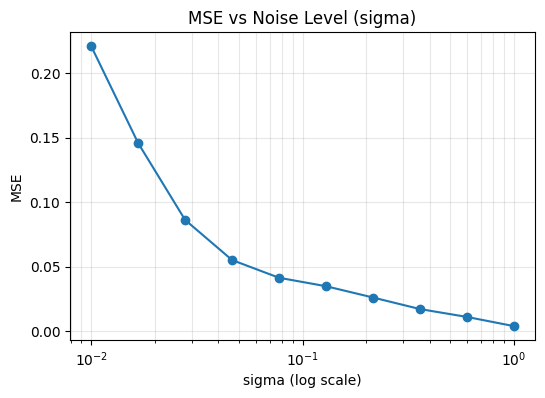

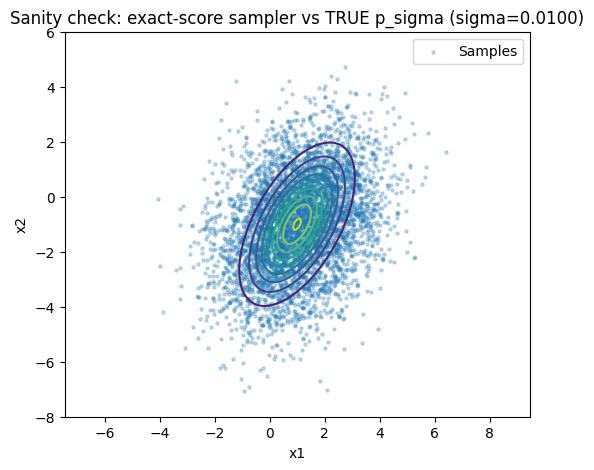


[Sanity check] Exact-score sampler mean: [ 1.03821   -0.9973961]
[Sanity check] True mean: [ 1. -1.]

[Sanity check] Exact-score sampler covariance:
 [[2.05388569 0.79390462]
 [0.79390462 3.02494593]]
[Sanity check] True covariance at final sigma:
 [[1.0001 0.8   ]
 [0.8    2.0001]]


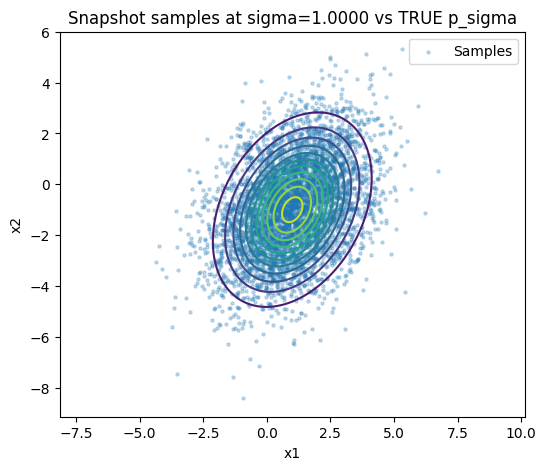

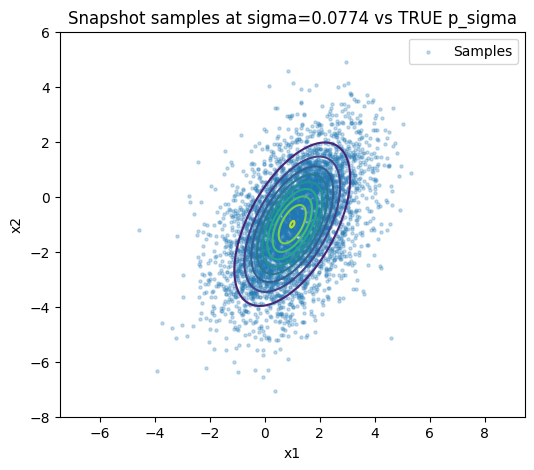

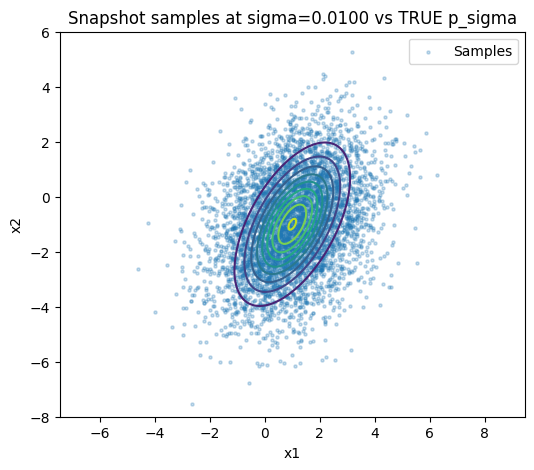

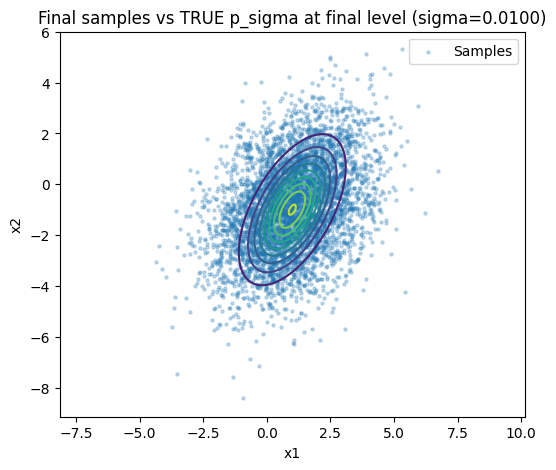


Final generated mean: [ 0.9982973 -0.8889116]
True mean: [ 1. -1.]

Final generated covariance:
 [[2.21707018 0.93624644]
 [0.93624644 3.13712798]]
True covariance at final sigma:
 [[1.0001 0.8   ]
 [0.8    2.0001]]

Fixed-sigma exact Langevin (sigma=0.1): target N(mu, Sigma + sigma^2 I), ordinary Langevin, no annealing


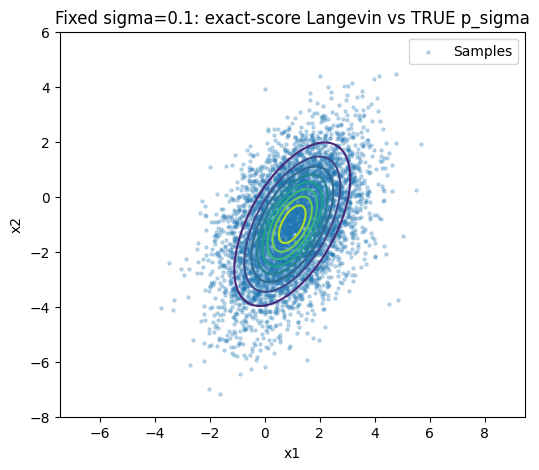


Sample mean: [ 0.98209697 -1.025114  ]
True mean (same for all sigma): [ 1. -1.]

Sample covariance:
 [[1.56283997 0.9640848 ]
 [0.9640848  2.80275996]]
True covariance at sigma:
 [[1.01 0.8 ]
 [0.8  2.01]]
Mean L2 error: 0.03084208913544378
Cov Frobenius error: 0.9939557488303186


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ============================================================
# 1) Data: correlated bivariate Gaussian p_data(x) = N(mu, Sigma)
# ============================================================
def sample_bivariate_normal(n: int, mu, Sigma, device="cpu"):
    mu = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma = torch.tensor(Sigma, dtype=torch.float32, device=device)
    L = torch.linalg.cholesky(Sigma)
    z = torch.randn(n, 2, device=device)
    return mu + z @ L.T


# ============================================================
# 2) MLP score model: s_theta(x_tilde, sigma)
#    input  = (x1, x2, log sigma)
#    output = (score1, score2)
# ============================================================
class ScoreNetMLP(nn.Module):
    def __init__(self, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_tilde, sigma):
        # sigma: (B,)  -> log_sigma: (B,1)
        log_sigma = torch.log(sigma).unsqueeze(1)
        inp = torch.cat([x_tilde, log_sigma], dim=1)  # (B,3)
        return self.net(inp)  # (B,2)


# ============================================================
# 3) VE denoising score matching (DSM) training loop
#    corruption: x_tilde = x + sigma * eps
#    target:     -(x_tilde - x)/sigma^2 = -eps/sigma
# ============================================================
def train_dsm(
    model,
    dataloader,
    sigmas,
    steps=5000,
    lr=1e-3,
    device="cpu",
    sigma_weight=True,
):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sigmas = torch.tensor(sigmas, dtype=torch.float32, device=device)  # (K,)

    it = iter(dataloader)
    for step in range(1, steps + 1):
        try:
            x = next(it)[0].to(device)  # (B,2)
        except StopIteration:
            it = iter(dataloader)
            x = next(it)[0].to(device)

        B = x.shape[0]

        # pick a sigma per datapoint (uniform over schedule)
        idx = torch.randint(0, sigmas.numel(), (B,), device=device)
        sigma = sigmas[idx]  # (B,)

        # add VE noise
        eps = torch.randn_like(x)  # (B,2)
        x_tilde = x + sigma.unsqueeze(1) * eps

        # DSM target = score of q(x_tilde|x)
        target = -eps / sigma.unsqueeze(1)  # (B,2)

        pred = model(x_tilde, sigma)  # (B,2)

        # common NCSN-style weighting
        if sigma_weight:
            w = (sigma**2).unsqueeze(1)  # (B,1)
            loss = ((pred - target) ** 2 * w).mean()
        else:
            loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 500 == 0:
            print(f"step {step:5d} | loss {loss.item():.6f}")

    return model


# ============================================================
# 4) True intermediate (noisy marginal) distribution for toy Gaussian
#
# If x ~ N(mu, Sigma) and x_tilde = x + sigma * eps, eps~N(0,I)
# then the marginal of x_tilde is:
#   p_sigma(x_tilde) = N(mu, Sigma + sigma^2 I)
# and its score is:
#   ∇ log p_sigma(x_tilde) = -(Sigma + sigma^2 I)^{-1} (x_tilde - mu)
# ============================================================
def true_noisy_marginal_score(x_tilde, mu, Sigma, sigma):
    device = x_tilde.device
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    Sigma_inv = torch.linalg.inv(Sigma_sigma)
    return -(x_tilde - mu_t) @ Sigma_inv.T


def sample_from_noisy_marginal(n_samples, mu, Sigma, sigma, device="cpu"):
    """
    Sample x ~ N(mu, Sigma + sigma^2 I), the VE noisy marginal at noise level sigma.
    Matches forward corruption marginal when data is N(mu, Sigma).
    """
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    L = torch.linalg.cholesky(Sigma_sigma)
    z = torch.randn(n_samples, 2, device=device)
    return mu_t + z @ L.T


@torch.no_grad()
def eval_mse_cosine_per_sigma(model, mu, Sigma, sigmas, device="cpu", n_test=5000):
    """
    Compare model(x, sigma) to TRUE noisy marginal score at each sigma.
    Returns arrays so you can plot MSE vs sigma.
    """
    model.eval()
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)

    mses, coses = [], []
    for s in sigmas:
        s = float(s)

        # sample x_tilde from the TRUE noisy marginal N(mu, Sigma + s^2 I)
        Sigma_sigma = Sigma_t + (s**2) * torch.eye(2, device=device)
        L = torch.linalg.cholesky(Sigma_sigma)
        z = torch.randn(n_test, 2, device=device)
        x_tilde = mu_t + z @ L.T

        sigma_batch = torch.full((n_test,), s, device=device)
        pred = model(x_tilde, sigma_batch)
        true = true_noisy_marginal_score(x_tilde, mu, Sigma, s)

        mse = ((pred - true) ** 2).mean().item()
        cos = F.cosine_similarity(pred, true, dim=1).mean().item()
        mses.append(mse)
        coses.append(cos)

    return np.array(mses), np.array(coses)


def plot_mse_vs_sigma(sigmas, mses):
    plt.figure(figsize=(6, 4))
    plt.plot(sigmas, mses, marker="o")
    plt.xscale("log")
    plt.xlabel("sigma (log scale)")
    plt.ylabel("MSE")
    plt.title("MSE vs Noise Level (sigma)")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


# ============================================================
# 5) VE sampling: Annealed Langevin dynamics
#    x <- x + eta * s_theta(x, sigma) + sqrt(2 eta) z
# ============================================================
@torch.no_grad()
def sample_annealed_langevin_with_snapshots(
    model,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
    mu=None,
    Sigma=None,
):
    """
    Runs annealed Langevin across a decreasing sigma schedule.
    Optionally stores x when we first reach each sigma in snapshot_sigmas.

    Returns:
      final_x: (n_samples,2) torch tensor
      snaps: dict {sigma_value: x_tensor_copy}
    """
    model.eval()
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    if mu is not None and Sigma is not None:
        x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)
    else:
        x = torch.randn(n_samples, 2, device=device) * sigma_max

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    # iterate from large -> small
    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())

        sigma_batch = torch.full((n_samples,), s_val, device=device)

        # NCSN-style annealed Langevin: normalize by sigma_min
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_batch) + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    # Optional final denoise at sigma_min (no injected noise)
    if denoise:
        s_min = float(sigma_min.item())
        sigma_batch = torch.full((n_samples,), s_min, device=device)
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            x = x + eta_denoise * model(x, sigma_batch)

    return x, snaps


@torch.no_grad()
def sample_annealed_langevin_exact_score_with_snapshots(
    mu,
    Sigma,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
):
    """
    Same annealed Langevin sampler, but using the TRUE score at each sigma.
    Useful sanity check to isolate sampling dynamics from score-learning error.
    """
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_val)
            x = x + eta * true_score + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    if denoise:
        s_min = float(sigma_min.item())
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_min)
            x = x + eta_denoise * true_score

    return x, snaps


@torch.no_grad()
def sample_fixed_sigma_exact_langevin(
    mu,
    Sigma,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    device="cpu",
    init_sigma=1.0,
):
    """
    Ordinary (non-annealed) Langevin dynamics at a single noise level sigma_fixed,
    using the exact score of the noisy marginal p_sigma = N(mu, Sigma + sigma_fixed^2 I).

        x <- x + eta * grad log p_sigma(x) + sqrt(2 eta) z

    Chains are initialised from N(mu, Sigma + init_sigma^2 I) (e.g. init_sigma=1.0
    matches a high-noise forward marginal) so the run is a convergence check toward p_sigma.
    """
    x = sample_from_noisy_marginal(n_samples, mu, Sigma, init_sigma, device=device)
    s_fixed = float(sigma_fixed)

    for _ in range(n_steps):
        z = torch.randn_like(x)
        score = true_noisy_marginal_score(x, mu, Sigma, s_fixed)
        x = x + eta * score + (2 * eta) ** 0.5 * z

    return x


def run_fixed_sigma_exact_langevin_experiment(
    mu,
    Sigma,
    device=None,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    init_sigma=1.0,
):
    """
    Separate experiment: fixed-sigma exact-score Langevin targeting p_sigma only.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print("\n" + "=" * 60)
    print(
        f"Fixed-sigma exact Langevin (sigma={sigma_fixed}): "
        f"target N(mu, Sigma + sigma^2 I), ordinary Langevin, no annealing"
    )
    print("=" * 60)

    x = sample_fixed_sigma_exact_langevin(
        mu,
        Sigma,
        sigma_fixed=sigma_fixed,
        n_samples=n_samples,
        n_steps=n_steps,
        eta=eta,
        device=device,
        init_sigma=init_sigma,
    )
    samples_np = x.cpu().numpy()

    plot_samples_vs_true_noisy_marginal(
        samples_np,
        mu,
        Sigma,
        sigma=sigma_fixed,
        levels=12,
        span=7.0,
        title=f"Fixed sigma={sigma_fixed}: exact-score Langevin vs TRUE p_sigma",
    )

    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64) + (sigma_fixed**2) * np.eye(2)
    mean_s = samples_np.mean(axis=0)
    cov_s = np.cov(samples_np.T)

    print("\nSample mean:", mean_s)
    print("True mean (same for all sigma):", mean_true)
    print("\nSample covariance:\n", cov_s)
    print("True covariance at sigma:\n", cov_true)
    print("Mean L2 error:", np.linalg.norm(mean_s - mean_true))
    print("Cov Frobenius error:", np.linalg.norm(cov_s - cov_true, ord="fro"))

    return x


# ============================================================
# 6) Plot: sampled points vs TRUE intermediate marginal contours
#    TRUE intermediate marginal at sigma is N(mu, Sigma + sigma^2 I)
# ============================================================
def gaussian_density_grid(mu, Sigma, x1, x2):
    """
    Compute 2D Gaussian density on a grid given by meshgrid(x1, x2).
    Returns Z with shape (len(x2), len(x1)) suitable for contour.
    """
    mu = np.array(mu, dtype=np.float64)
    Sigma = np.array(Sigma, dtype=np.float64)
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)

    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    X = np.stack([X1, X2], axis=-1)  # (...,2)
    D = X - mu
    quad = np.einsum("...i,ij,...j->...", D, inv, D)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    Z = norm * np.exp(-0.5 * quad)
    return X1, X2, Z


def plot_samples_vs_true_noisy_marginal(samples_np, mu, Sigma, sigma, levels=12, span=7.0, title=None):
    """
    Overlay sampled points with contours of the TRUE noisy marginal at this sigma:
      N(mu, Sigma + sigma^2 I)
    """
    Sigma = np.array(Sigma, dtype=np.float64)
    Sigma_sigma = Sigma + (sigma**2) * np.eye(2)

    x1 = np.linspace(mu[0] - span, mu[0] + span, 200)
    x2 = np.linspace(mu[1] - span, mu[1] + span, 200)
    X1, X2, Z = gaussian_density_grid(mu, Sigma_sigma, x1, x2)

    plt.figure(figsize=(6, 5))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=5, alpha=0.25, label="Samples")
    plt.contour(X1, X2, Z, levels=levels)
    plt.xlabel("x1")
    plt.ylabel("x2")
    if title is None:
        title = f"Samples vs TRUE noisy marginal contours (sigma={sigma:.4f})"
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()


# ============================================================
# 7) Run everything
# ============================================================
def run_experiment():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(0)
    np.random.seed(0)

    # --- toy target distribution ---
    mu = [1.0, -1.0]
    Sigma = [[1.0, 0.8],
             [0.8, 2.0]]

    # --- dataset ---
    N = 20000
    x = sample_bivariate_normal(N, mu, Sigma, device=device).cpu()
    loader = DataLoader(TensorDataset(x), batch_size=512, shuffle=True, drop_last=True)

    # --- VE noise schedule (your "time parameter" in practice) ---
    sigmas = np.geomspace(1.0, 0.01, 10).astype(np.float32)
    sigma_final = float(sigmas[-1])

    # --- model ---
    model = ScoreNetMLP(hidden_dim=128).to(device)

    # --- train ---
    train_dsm(model, loader, sigmas, steps=5000, lr=1e-3, device=device, sigma_weight=True)

    # --- diagnostics: score accuracy vs TRUE intermediate scores ---
    mses, coses = eval_mse_cosine_per_sigma(model, mu, Sigma, sigmas, device=device, n_test=8000)
    print("\nDiagnostics vs TRUE noisy marginal score")
    print("   sigma        MSE        cosine")
    for s, mse, cos in zip(sigmas, mses, coses):
        print(f"{float(s):8.4f}  {mse:10.6f}   {cos:8.4f}")

    plot_mse_vs_sigma(sigmas, mses)

    # --- sampling + snapshots at intermediate sigmas ---
    snapshot_sigmas = [float(sigmas[0]), float(sigmas[len(sigmas)//2]), float(sigmas[-1])]

    # --- sanity check: run the same sampler with the TRUE score ---
    exact_x, _ = sample_annealed_langevin_exact_score_with_snapshots(
        mu,
        Sigma,
        sigmas,
        n_samples=5000,
        n_steps_each=500,
        step_scale=1e-5,
        device=device,
        snapshot_sigmas=snapshot_sigmas,
        extra_steps_at_end=1500,
        denoise=True,
        denoise_steps=100,
    )
    exact_np = exact_x.cpu().numpy()
    plot_samples_vs_true_noisy_marginal(
        exact_np, mu, Sigma, sigma=sigma_final, levels=12, span=7.0,
        title=f"Sanity check: exact-score sampler vs TRUE p_sigma (sigma={sigma_final:.4f})"
    )
    print("\n[Sanity check] Exact-score sampler mean:", exact_np.mean(axis=0))
    print("[Sanity check] True mean:", np.array(mu))
    print("\n[Sanity check] Exact-score sampler covariance:\n", np.cov(exact_np.T))
    print("[Sanity check] True covariance at final sigma:\n", np.array(Sigma) + (sigma_final**2) * np.eye(2))

    final_x, snaps = sample_annealed_langevin_with_snapshots(
        model,
        sigmas,
        n_samples=5000,
        n_steps_each=500,
        step_scale=1e-5,
        device=device,
        snapshot_sigmas=snapshot_sigmas,
        extra_steps_at_end=1500,
        denoise=True,
        denoise_steps=100,
        mu=mu,
        Sigma=Sigma,
    )

    # plot overlays: sampled state at sigma vs TRUE marginal at same sigma
    for s in snapshot_sigmas:
        x_s = snaps[s].cpu().numpy()
        plot_samples_vs_true_noisy_marginal(
            x_s, mu, Sigma, sigma=s, levels=12, span=7.0,
            title=f"Snapshot samples at sigma={s:.4f} vs TRUE p_sigma"
        )

    # final result vs TRUE final noisy marginal
    final_np = final_x.cpu().numpy()
    plot_samples_vs_true_noisy_marginal(
        final_np, mu, Sigma, sigma=sigma_final, levels=12, span=7.0,
        title=f"Final samples vs TRUE p_sigma at final level (sigma={sigma_final:.4f})"
    )

    # quick numeric sanity checks
    print("\nFinal generated mean:", final_np.mean(axis=0))
    print("True mean:", np.array(mu))
    print("\nFinal generated covariance:\n", np.cov(final_np.T))
    print("True covariance at final sigma:\n", np.array(Sigma) + (sigma_final**2) * np.eye(2))

    # ============================================================
    # Separate check (same run): fixed-sigma ordinary Langevin with exact score
    # Target: p_sigma at sigma=0.1
    # ============================================================
    run_fixed_sigma_exact_langevin_experiment(mu, Sigma, device=device, sigma_fixed=0.1, eta=1e-5)

    return model, sigmas, mu, Sigma


if __name__ == "__main__":
    run_experiment()

step   500 | loss 0.887534
step  1000 | loss 0.953802
step  1500 | loss 0.837106
step  2000 | loss 0.887523
step  2500 | loss 0.907862
step  3000 | loss 0.947181
step  3500 | loss 0.866949
step  4000 | loss 0.927982
step  4500 | loss 0.843044
step  5000 | loss 0.914781


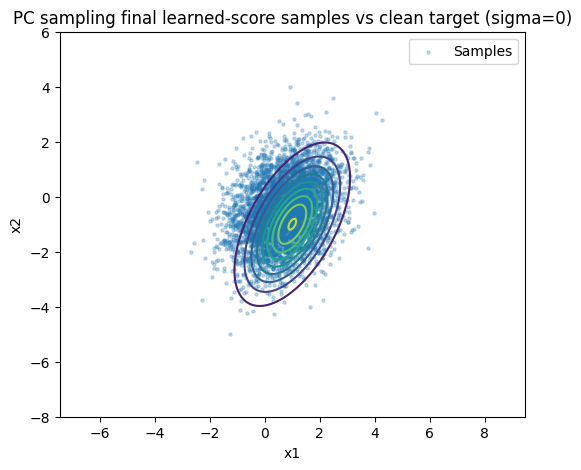


Global diagnostics (PC final samples vs clean target)
Generated mean: [ 0.71208394 -0.5005071 ]
True mean:      [ 1. -1.]
Mean error:     [-0.28791606  0.49949288]

Generated covariance:
 [[0.87844311 0.31677885]
 [0.31677885 1.20612284]]
True covariance:
 [[1.  0.8]
 [0.8 2. ]]
Covariance error:
 [[-0.12155689 -0.48322115]
 [-0.48322115 -0.79387716]]


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ============================================================
# 1) Data: correlated bivariate Gaussian p_data(x) = N(mu, Sigma)
# ============================================================
def sample_bivariate_normal(n: int, mu, Sigma, device="cpu"):
    mu = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma = torch.tensor(Sigma, dtype=torch.float32, device=device)
    L = torch.linalg.cholesky(Sigma)
    z = torch.randn(n, 2, device=device)
    return mu + z @ L.T


# ============================================================
# 2) MLP score model: s_theta(x_tilde, sigma)
#    input  = (x1, x2, log sigma)
#    output = (score1, score2)
# ============================================================
class ScoreNetMLP(nn.Module):
    def __init__(self, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_tilde, sigma):
        # sigma: (B,)  -> log_sigma: (B,1)
        log_sigma = torch.log(sigma).unsqueeze(1)
        inp = torch.cat([x_tilde, log_sigma], dim=1)  # (B,3)
        return self.net(inp)  # (B,2)


# ============================================================
# 3) VE denoising score matching (DSM) training loop
#    corruption: x_tilde = x + sigma * eps
#    target:     -(x_tilde - x)/sigma^2 = -eps/sigma
# ============================================================
def train_dsm(
    model,
    dataloader,
    sigmas,
    steps=5000,
    lr=1e-3,
    device="cpu",
    sigma_weight=True,
):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sigmas = torch.tensor(sigmas, dtype=torch.float32, device=device)  # (K,)

    it = iter(dataloader)
    for step in range(1, steps + 1):
        try:
            x = next(it)[0].to(device)  # (B,2)
        except StopIteration:
            it = iter(dataloader)
            x = next(it)[0].to(device)

        B = x.shape[0]

        # pick a sigma per datapoint (uniform over schedule)
        idx = torch.randint(0, sigmas.numel(), (B,), device=device)
        sigma = sigmas[idx]  # (B,)

        # add VE noise
        eps = torch.randn_like(x)  # (B,2)
        x_tilde = x + sigma.unsqueeze(1) * eps

        # DSM target = score of q(x_tilde|x)
        target = -eps / sigma.unsqueeze(1)  # (B,2)

        pred = model(x_tilde, sigma)  # (B,2)

        # common NCSN-style weighting
        if sigma_weight:
            w = (sigma**2).unsqueeze(1)  # (B,1)
            loss = ((pred - target) ** 2 * w).mean()
        else:
            loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 500 == 0:
            print(f"step {step:5d} | loss {loss.item():.6f}")

    return model


# ============================================================
# 4) True intermediate (noisy marginal) distribution for toy Gaussian
#
# If x ~ N(mu, Sigma) and x_tilde = x + sigma * eps, eps~N(0,I)
# then the marginal of x_tilde is:
#   p_sigma(x_tilde) = N(mu, Sigma + sigma^2 I)
# and its score is:
#   ∇ log p_sigma(x_tilde) = -(Sigma + sigma^2 I)^{-1} (x_tilde - mu)
# ============================================================
def true_noisy_marginal_score(x_tilde, mu, Sigma, sigma):
    device = x_tilde.device
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    Sigma_inv = torch.linalg.inv(Sigma_sigma)
    return -(x_tilde - mu_t) @ Sigma_inv.T


def sample_from_noisy_marginal(n_samples, mu, Sigma, sigma, device="cpu"):
    """
    Sample x ~ N(mu, Sigma + sigma^2 I), the VE noisy marginal at noise level sigma.
    Matches forward corruption marginal when data is N(mu, Sigma).
    """
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    L = torch.linalg.cholesky(Sigma_sigma)
    z = torch.randn(n_samples, 2, device=device)
    return mu_t + z @ L.T


@torch.no_grad()
def eval_mse_cosine_per_sigma(model, mu, Sigma, sigmas, device="cpu", n_test=5000):
    """
    Compare model(x, sigma) to TRUE noisy marginal score at each sigma.
    Returns arrays so you can plot MSE vs sigma.
    """
    model.eval()
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)

    mses, coses = [], []
    for s in sigmas:
        s = float(s)

        # sample x_tilde from the TRUE noisy marginal N(mu, Sigma + s^2 I)
        Sigma_sigma = Sigma_t + (s**2) * torch.eye(2, device=device)
        L = torch.linalg.cholesky(Sigma_sigma)
        z = torch.randn(n_test, 2, device=device)
        x_tilde = mu_t + z @ L.T

        sigma_batch = torch.full((n_test,), s, device=device)
        pred = model(x_tilde, sigma_batch)
        true = true_noisy_marginal_score(x_tilde, mu, Sigma, s)

        mse = ((pred - true) ** 2).mean().item()
        cos = F.cosine_similarity(pred, true, dim=1).mean().item()
        mses.append(mse)
        coses.append(cos)

    return np.array(mses), np.array(coses)


def plot_mse_vs_sigma(sigmas, mses):
    plt.figure(figsize=(6, 4))
    plt.plot(sigmas, mses, marker="o")
    plt.xscale("log")
    plt.xlabel("sigma (log scale)")
    plt.ylabel("MSE")
    plt.title("MSE vs Noise Level (sigma)")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


# ============================================================
# 5) VE sampling: Annealed Langevin dynamics
#    x <- x + eta * s_theta(x, sigma) + sqrt(2 eta) z
# ============================================================
@torch.no_grad()
def sample_annealed_langevin_with_snapshots(
    model,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
    mu=None,
    Sigma=None,
):
    """
    Runs annealed Langevin across a decreasing sigma schedule.
    Optionally stores x when we first reach each sigma in snapshot_sigmas.

    Returns:
      final_x: (n_samples,2) torch tensor
      snaps: dict {sigma_value: x_tensor_copy}
    """
    model.eval()
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    if mu is not None and Sigma is not None:
        x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)
    else:
        x = torch.randn(n_samples, 2, device=device) * sigma_max

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    # iterate from large -> small
    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())

        sigma_batch = torch.full((n_samples,), s_val, device=device)

        # NCSN-style annealed Langevin: normalize by sigma_min
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_batch) + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    # Optional final denoise at sigma_min (no injected noise)
    if denoise:
        s_min = float(sigma_min.item())
        sigma_batch = torch.full((n_samples,), s_min, device=device)
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            x = x + eta_denoise * model(x, sigma_batch)

    return x, snaps


@torch.no_grad()
def sample_pc_reverse_sde(
    model,
    sigmas,
    n_samples=5000,
    n_corrector_steps=2,
    corrector_step_scale=1e-5,
    device="cpu",
    denoise=False,
):
    """
    Predictor-Corrector (PC) sampler for VE using learned score.

    Predictor: reverse-SDE Euler-Maruyama step between adjacent sigmas
      x <- x + (sigma_i^2 - sigma_{i+1}^2) s_theta(x, sigma_i)
             + sqrt(sigma_i^2 - sigma_{i+1}^2) z

    Corrector: Langevin refinement at fixed sigma_{i+1}
      x <- x + eta s_theta(x, sigma_{i+1}) + sqrt(2 eta) z
    """
    model.eval()
    sigmas_sorted = np.array(sorted([float(s) for s in sigmas], reverse=True), dtype=np.float32)
    sigmas_t = torch.tensor(sigmas_sorted, dtype=torch.float32, device=device)
    sigma_min = sigmas_t[-1]

    # VE prior at largest noise level
    x = torch.randn(n_samples, 2, device=device) * sigmas_t[0]

    for i in range(len(sigmas_t) - 1):
        sigma_i = float(sigmas_t[i].item())
        sigma_next = float(sigmas_t[i + 1].item())

        # Predictor (reverse SDE Euler-Maruyama)
        sigma_i_batch = torch.full((n_samples,), sigma_i, device=device)
        score_i = model(x, sigma_i_batch)
        delta_var = sigma_i**2 - sigma_next**2
        z = torch.randn_like(x)
        x = x + delta_var * score_i + (delta_var**0.5) * z

        # Corrector (Langevin at sigma_next)
        sigma_next_batch = torch.full((n_samples,), sigma_next, device=device)
        eta = float(corrector_step_scale * ((sigma_next / float(sigma_min.item())) ** 2))
        for _ in range(n_corrector_steps):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_next_batch) + (2 * eta) ** 0.5 * z

    if denoise:
        sigma_last = float(sigma_min.item())
        sigma_last_batch = torch.full((n_samples,), sigma_last, device=device)
        x = x + (sigma_last**2) * model(x, sigma_last_batch)

    return x


@torch.no_grad()
def sample_annealed_langevin_exact_score_with_snapshots(
    mu,
    Sigma,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
):
    """
    Same annealed Langevin sampler, but using the TRUE score at each sigma.
    Useful sanity check to isolate sampling dynamics from score-learning error.
    """
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_val)
            x = x + eta * true_score + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    if denoise:
        s_min = float(sigma_min.item())
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_min)
            x = x + eta_denoise * true_score

    return x, snaps


@torch.no_grad()
def sample_fixed_sigma_exact_langevin(
    mu,
    Sigma,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    device="cpu",
    init_sigma=1.0,
):
    """
    Ordinary (non-annealed) Langevin dynamics at a single noise level sigma_fixed,
    using the exact score of the noisy marginal p_sigma = N(mu, Sigma + sigma_fixed^2 I).

        x <- x + eta * grad log p_sigma(x) + sqrt(2 eta) z

    Chains are initialised from N(mu, Sigma + init_sigma^2 I) (e.g. init_sigma=1.0
    matches a high-noise forward marginal) so the run is a convergence check toward p_sigma.
    """
    x = sample_from_noisy_marginal(n_samples, mu, Sigma, init_sigma, device=device)
    s_fixed = float(sigma_fixed)

    for _ in range(n_steps):
        z = torch.randn_like(x)
        score = true_noisy_marginal_score(x, mu, Sigma, s_fixed)
        x = x + eta * score + (2 * eta) ** 0.5 * z

    return x


def run_fixed_sigma_exact_langevin_experiment(
    mu,
    Sigma,
    device=None,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    init_sigma=1.0,
):
    """
    Separate experiment: fixed-sigma exact-score Langevin targeting p_sigma only.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print("\n" + "=" * 60)
    print(
        f"Fixed-sigma exact Langevin (sigma={sigma_fixed}): "
        f"target N(mu, Sigma + sigma^2 I), ordinary Langevin, no annealing"
    )
    print("=" * 60)

    x = sample_fixed_sigma_exact_langevin(
        mu,
        Sigma,
        sigma_fixed=sigma_fixed,
        n_samples=n_samples,
        n_steps=n_steps,
        eta=eta,
        device=device,
        init_sigma=init_sigma,
    )
    samples_np = x.cpu().numpy()

    plot_samples_vs_true_noisy_marginal(
        samples_np,
        mu,
        Sigma,
        sigma=sigma_fixed,
        levels=12,
        span=7.0,
        title=f"Fixed sigma={sigma_fixed}: exact-score Langevin vs TRUE p_sigma",
    )

    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64) + (sigma_fixed**2) * np.eye(2)
    mean_s = samples_np.mean(axis=0)
    cov_s = np.cov(samples_np.T)

    print("\nSample mean:", mean_s)
    print("True mean (same for all sigma):", mean_true)
    print("\nSample covariance:\n", cov_s)
    print("True covariance at sigma:\n", cov_true)
    print("Mean L2 error:", np.linalg.norm(mean_s - mean_true))
    print("Cov Frobenius error:", np.linalg.norm(cov_s - cov_true, ord="fro"))

    return x


# ============================================================
# 6) Plot: sampled points vs TRUE intermediate marginal contours
#    TRUE intermediate marginal at sigma is N(mu, Sigma + sigma^2 I)
# ============================================================
def gaussian_density_grid(mu, Sigma, x1, x2):
    """
    Compute 2D Gaussian density on a grid given by meshgrid(x1, x2).
    Returns Z with shape (len(x2), len(x1)) suitable for contour.
    """
    mu = np.array(mu, dtype=np.float64)
    Sigma = np.array(Sigma, dtype=np.float64)
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)

    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    X = np.stack([X1, X2], axis=-1)  # (...,2)
    D = X - mu
    quad = np.einsum("...i,ij,...j->...", D, inv, D)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    Z = norm * np.exp(-0.5 * quad)
    return X1, X2, Z


def plot_samples_vs_true_noisy_marginal(samples_np, mu, Sigma, sigma, levels=12, span=7.0, title=None):
    """
    Overlay sampled points with contours of the TRUE noisy marginal at this sigma:
      N(mu, Sigma + sigma^2 I)
    """
    Sigma = np.array(Sigma, dtype=np.float64)
    Sigma_sigma = Sigma + (sigma**2) * np.eye(2)

    x1 = np.linspace(mu[0] - span, mu[0] + span, 200)
    x2 = np.linspace(mu[1] - span, mu[1] + span, 200)
    X1, X2, Z = gaussian_density_grid(mu, Sigma_sigma, x1, x2)

    plt.figure(figsize=(6, 5))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=5, alpha=0.25, label="Samples")
    plt.contour(X1, X2, Z, levels=levels)
    plt.xlabel("x1")
    plt.ylabel("x2")
    if title is None:
        title = f"Samples vs TRUE noisy marginal contours (sigma={sigma:.4f})"
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()


# ============================================================
# 7) Run everything
# ============================================================
def run_experiment():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(0)
    np.random.seed(0)

    # --- toy target distribution ---
    mu = [1.0, -1.0]
    Sigma = [[1.0, 0.8],
             [0.8, 2.0]]

    # --- dataset ---
    N = 20000
    x = sample_bivariate_normal(N, mu, Sigma, device=device).cpu()
    loader = DataLoader(TensorDataset(x), batch_size=512, shuffle=True, drop_last=True)

    # --- VE noise schedule (your "time parameter" in practice) ---
    sigmas = np.geomspace(1.0, 0.01, 10).astype(np.float32)
    # --- model ---
    model = ScoreNetMLP(hidden_dim=128).to(device)

    # --- train ---
    train_dsm(model, loader, sigmas, steps=5000, lr=1e-3, device=device, sigma_weight=True)

    # --- PC sampling (predictor + corrector) with learned score ---
    final_x = sample_pc_reverse_sde(
        model,
        sigmas,
        n_samples=5000,
        n_corrector_steps=2,
        corrector_step_scale=1e-5,
        device=device,
        denoise=True,
    )

    # Only show final learned samples against clean target p_data (sigma=0)
    final_np = final_x.cpu().numpy()
    plot_samples_vs_true_noisy_marginal(
        final_np, mu, Sigma, sigma=0.0, levels=12, span=7.0,
        title="PC sampling final learned-score samples vs clean target (sigma=0)"
    )

    # Global diagnostics against clean target distribution
    mean_gen = final_np.mean(axis=0)
    cov_gen = np.cov(final_np.T)
    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64)

    print("\nGlobal diagnostics (PC final samples vs clean target)")
    print("Generated mean:", mean_gen)
    print("True mean:     ", mean_true)
    print("Mean error:    ", mean_gen - mean_true)
    print("\nGenerated covariance:\n", cov_gen)
    print("True covariance:\n", cov_true)
    print("Covariance error:\n", cov_gen - cov_true)

    return model, sigmas, mu, Sigma


if __name__ == "__main__":
    run_experiment()


step   500 | loss 0.887534
step  1000 | loss 0.953802
step  1500 | loss 0.837106
step  2000 | loss 0.887523
step  2500 | loss 0.907862
step  3000 | loss 0.947181
step  3500 | loss 0.866949
step  4000 | loss 0.927982
step  4500 | loss 0.843044
step  5000 | loss 0.914781


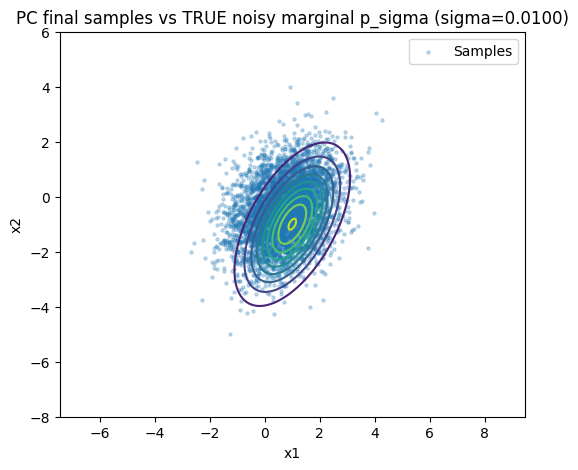


Global diagnostics (PC final samples vs TRUE noisy marginal)
(sigma = 0.010000, target N(mu, Sigma + sigma^2 I))
Generated mean: [ 0.71208394 -0.5005071 ]
True mean:      [ 1. -1.]
Mean error:     [-0.28791606  0.49949288]

Generated covariance:
 [[0.87844311 0.31677885]
 [0.31677885 1.20612284]]
True covariance (noisy marginal):
 [[1.0001 0.8   ]
 [0.8    2.0001]]
Covariance error:
 [[-0.12165689 -0.48322115]
 [-0.48322115 -0.79397716]]


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ============================================================
# 1) Data: correlated bivariate Gaussian p_data(x) = N(mu, Sigma)
# ============================================================
def sample_bivariate_normal(n: int, mu, Sigma, device="cpu"):
    mu = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma = torch.tensor(Sigma, dtype=torch.float32, device=device)
    L = torch.linalg.cholesky(Sigma)
    z = torch.randn(n, 2, device=device)
    return mu + z @ L.T


# ============================================================
# 2) MLP score model: s_theta(x_tilde, sigma)
#    input  = (x1, x2, log sigma)
#    output = (score1, score2)
# ============================================================
class ScoreNetMLP(nn.Module):
    def __init__(self, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_tilde, sigma):
        # sigma: (B,)  -> log_sigma: (B,1)
        log_sigma = torch.log(sigma).unsqueeze(1)
        inp = torch.cat([x_tilde, log_sigma], dim=1)  # (B,3)
        return self.net(inp)  # (B,2)


# ============================================================
# 3) VE denoising score matching (DSM) training loop
#    corruption: x_tilde = x + sigma * eps
#    target:     -(x_tilde - x)/sigma^2 = -eps/sigma
# ============================================================
def train_dsm(
    model,
    dataloader,
    sigmas,
    steps=5000,
    lr=1e-3,
    device="cpu",
    sigma_weight=True,
):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sigmas = torch.tensor(sigmas, dtype=torch.float32, device=device)  # (K,)

    it = iter(dataloader)
    for step in range(1, steps + 1):
        try:
            x = next(it)[0].to(device)  # (B,2)
        except StopIteration:
            it = iter(dataloader)
            x = next(it)[0].to(device)

        B = x.shape[0]

        # pick a sigma per datapoint (uniform over schedule)
        idx = torch.randint(0, sigmas.numel(), (B,), device=device)
        sigma = sigmas[idx]  # (B,)

        # add VE noise
        eps = torch.randn_like(x)  # (B,2)
        x_tilde = x + sigma.unsqueeze(1) * eps

        # DSM target = score of q(x_tilde|x)
        target = -eps / sigma.unsqueeze(1)  # (B,2)

        pred = model(x_tilde, sigma)  # (B,2)

        # common NCSN-style weighting
        if sigma_weight:
            w = (sigma**2).unsqueeze(1)  # (B,1)
            loss = ((pred - target) ** 2 * w).mean()
        else:
            loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 500 == 0:
            print(f"step {step:5d} | loss {loss.item():.6f}")

    return model


# ============================================================
# 4) True intermediate (noisy marginal) distribution for toy Gaussian
#
# If x ~ N(mu, Sigma) and x_tilde = x + sigma * eps, eps~N(0,I)
# then the marginal of x_tilde is:
#   p_sigma(x_tilde) = N(mu, Sigma + sigma^2 I)
# and its score is:
#   ∇ log p_sigma(x_tilde) = -(Sigma + sigma^2 I)^{-1} (x_tilde - mu)
# ============================================================
def true_noisy_marginal_score(x_tilde, mu, Sigma, sigma):
    device = x_tilde.device
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    Sigma_inv = torch.linalg.inv(Sigma_sigma)
    return -(x_tilde - mu_t) @ Sigma_inv.T


def sample_from_noisy_marginal(n_samples, mu, Sigma, sigma, device="cpu"):
    """
    Sample x ~ N(mu, Sigma + sigma^2 I), the VE noisy marginal at noise level sigma.
    Matches forward corruption marginal when data is N(mu, Sigma).
    """
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    L = torch.linalg.cholesky(Sigma_sigma)
    z = torch.randn(n_samples, 2, device=device)
    return mu_t + z @ L.T


@torch.no_grad()
def eval_mse_cosine_per_sigma(model, mu, Sigma, sigmas, device="cpu", n_test=5000):
    """
    Compare model(x, sigma) to TRUE noisy marginal score at each sigma.
    Returns arrays so you can plot MSE vs sigma.
    """
    model.eval()
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)

    mses, coses = [], []
    for s in sigmas:
        s = float(s)

        # sample x_tilde from the TRUE noisy marginal N(mu, Sigma + s^2 I)
        Sigma_sigma = Sigma_t + (s**2) * torch.eye(2, device=device)
        L = torch.linalg.cholesky(Sigma_sigma)
        z = torch.randn(n_test, 2, device=device)
        x_tilde = mu_t + z @ L.T

        sigma_batch = torch.full((n_test,), s, device=device)
        pred = model(x_tilde, sigma_batch)
        true = true_noisy_marginal_score(x_tilde, mu, Sigma, s)

        mse = ((pred - true) ** 2).mean().item()
        cos = F.cosine_similarity(pred, true, dim=1).mean().item()
        mses.append(mse)
        coses.append(cos)

    return np.array(mses), np.array(coses)


def plot_mse_vs_sigma(sigmas, mses):
    plt.figure(figsize=(6, 4))
    plt.plot(sigmas, mses, marker="o")
    plt.xscale("log")
    plt.xlabel("sigma (log scale)")
    plt.ylabel("MSE")
    plt.title("MSE vs Noise Level (sigma)")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


# ============================================================
# 5) VE sampling: Annealed Langevin dynamics
#    x <- x + eta * s_theta(x, sigma) + sqrt(2 eta) z
# ============================================================
@torch.no_grad()
def sample_annealed_langevin_with_snapshots(
    model,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
    mu=None,
    Sigma=None,
):
    """
    Runs annealed Langevin across a decreasing sigma schedule.
    Optionally stores x when we first reach each sigma in snapshot_sigmas.

    Returns:
      final_x: (n_samples,2) torch tensor
      snaps: dict {sigma_value: x_tensor_copy}
    """
    model.eval()
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    if mu is not None and Sigma is not None:
        x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)
    else:
        x = torch.randn(n_samples, 2, device=device) * sigma_max

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    # iterate from large -> small
    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())

        sigma_batch = torch.full((n_samples,), s_val, device=device)

        # NCSN-style annealed Langevin: normalize by sigma_min
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_batch) + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    # Optional final denoise at sigma_min (no injected noise)
    if denoise:
        s_min = float(sigma_min.item())
        sigma_batch = torch.full((n_samples,), s_min, device=device)
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            x = x + eta_denoise * model(x, sigma_batch)

    return x, snaps


@torch.no_grad()
def sample_pc_reverse_sde(
    model,
    sigmas,
    n_samples=5000,
    n_corrector_steps=2,
    corrector_step_scale=1e-5,
    device="cpu",
    denoise=False,
):
    """
    Predictor-Corrector (PC) sampler for VE using learned score.

    Predictor: reverse-SDE Euler-Maruyama step between adjacent sigmas
      x <- x + (sigma_i^2 - sigma_{i+1}^2) s_theta(x, sigma_i)
             + sqrt(sigma_i^2 - sigma_{i+1}^2) z

    Corrector: Langevin refinement at fixed sigma_{i+1}
      x <- x + eta s_theta(x, sigma_{i+1}) + sqrt(2 eta) z
    """
    model.eval()
    sigmas_sorted = np.array(sorted([float(s) for s in sigmas], reverse=True), dtype=np.float32)
    sigmas_t = torch.tensor(sigmas_sorted, dtype=torch.float32, device=device)
    sigma_min = sigmas_t[-1]

    # VE prior at largest noise level
    x = torch.randn(n_samples, 2, device=device) * sigmas_t[0]

    for i in range(len(sigmas_t) - 1):
        sigma_i = float(sigmas_t[i].item())
        sigma_next = float(sigmas_t[i + 1].item())

        # Predictor (reverse SDE Euler-Maruyama)
        sigma_i_batch = torch.full((n_samples,), sigma_i, device=device)
        score_i = model(x, sigma_i_batch)
        delta_var = sigma_i**2 - sigma_next**2
        z = torch.randn_like(x)
        x = x + delta_var * score_i + (delta_var**0.5) * z

        # Corrector (Langevin at sigma_next)
        sigma_next_batch = torch.full((n_samples,), sigma_next, device=device)
        eta = float(corrector_step_scale * ((sigma_next / float(sigma_min.item())) ** 2))
        for _ in range(n_corrector_steps):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_next_batch) + (2 * eta) ** 0.5 * z

    if denoise:
        sigma_last = float(sigma_min.item())
        sigma_last_batch = torch.full((n_samples,), sigma_last, device=device)
        x = x + (sigma_last**2) * model(x, sigma_last_batch)

    return x


@torch.no_grad()
def sample_annealed_langevin_exact_score_with_snapshots(
    mu,
    Sigma,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
):
    """
    Same annealed Langevin sampler, but using the TRUE score at each sigma.
    Useful sanity check to isolate sampling dynamics from score-learning error.
    """
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_val)
            x = x + eta * true_score + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    if denoise:
        s_min = float(sigma_min.item())
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_min)
            x = x + eta_denoise * true_score

    return x, snaps


@torch.no_grad()
def sample_fixed_sigma_exact_langevin(
    mu,
    Sigma,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    device="cpu",
    init_sigma=1.0,
):
    """
    Ordinary (non-annealed) Langevin dynamics at a single noise level sigma_fixed,
    using the exact score of the noisy marginal p_sigma = N(mu, Sigma + sigma_fixed^2 I).

        x <- x + eta * grad log p_sigma(x) + sqrt(2 eta) z

    Chains are initialised from N(mu, Sigma + init_sigma^2 I) (e.g. init_sigma=1.0
    matches a high-noise forward marginal) so the run is a convergence check toward p_sigma.
    """
    x = sample_from_noisy_marginal(n_samples, mu, Sigma, init_sigma, device=device)
    s_fixed = float(sigma_fixed)

    for _ in range(n_steps):
        z = torch.randn_like(x)
        score = true_noisy_marginal_score(x, mu, Sigma, s_fixed)
        x = x + eta * score + (2 * eta) ** 0.5 * z

    return x


def run_fixed_sigma_exact_langevin_experiment(
    mu,
    Sigma,
    device=None,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    init_sigma=1.0,
):
    """
    Separate experiment: fixed-sigma exact-score Langevin targeting p_sigma only.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print("\n" + "=" * 60)
    print(
        f"Fixed-sigma exact Langevin (sigma={sigma_fixed}): "
        f"target N(mu, Sigma + sigma^2 I), ordinary Langevin, no annealing"
    )
    print("=" * 60)

    x = sample_fixed_sigma_exact_langevin(
        mu,
        Sigma,
        sigma_fixed=sigma_fixed,
        n_samples=n_samples,
        n_steps=n_steps,
        eta=eta,
        device=device,
        init_sigma=init_sigma,
    )
    samples_np = x.cpu().numpy()

    plot_samples_vs_true_noisy_marginal(
        samples_np,
        mu,
        Sigma,
        sigma=sigma_fixed,
        levels=12,
        span=7.0,
        title=f"Fixed sigma={sigma_fixed}: exact-score Langevin vs TRUE p_sigma",
    )

    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64) + (sigma_fixed**2) * np.eye(2)
    mean_s = samples_np.mean(axis=0)
    cov_s = np.cov(samples_np.T)

    print("\nSample mean:", mean_s)
    print("True mean (same for all sigma):", mean_true)
    print("\nSample covariance:\n", cov_s)
    print("True covariance at sigma:\n", cov_true)
    print("Mean L2 error:", np.linalg.norm(mean_s - mean_true))
    print("Cov Frobenius error:", np.linalg.norm(cov_s - cov_true, ord="fro"))

    return x


# ============================================================
# 6) Plot: sampled points vs TRUE intermediate marginal contours
#    TRUE intermediate marginal at sigma is N(mu, Sigma + sigma^2 I)
# ============================================================
def gaussian_density_grid(mu, Sigma, x1, x2):
    """
    Compute 2D Gaussian density on a grid given by meshgrid(x1, x2).
    Returns Z with shape (len(x2), len(x1)) suitable for contour.
    """
    mu = np.array(mu, dtype=np.float64)
    Sigma = np.array(Sigma, dtype=np.float64)
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)

    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    X = np.stack([X1, X2], axis=-1)  # (...,2)
    D = X - mu
    quad = np.einsum("...i,ij,...j->...", D, inv, D)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    Z = norm * np.exp(-0.5 * quad)
    return X1, X2, Z


def plot_samples_vs_true_noisy_marginal(samples_np, mu, Sigma, sigma, levels=12, span=7.0, title=None):
    """
    Overlay sampled points with contours of the TRUE noisy marginal at this sigma:
      N(mu, Sigma + sigma^2 I)
    """
    Sigma = np.array(Sigma, dtype=np.float64)
    Sigma_sigma = Sigma + (sigma**2) * np.eye(2)

    x1 = np.linspace(mu[0] - span, mu[0] + span, 200)
    x2 = np.linspace(mu[1] - span, mu[1] + span, 200)
    X1, X2, Z = gaussian_density_grid(mu, Sigma_sigma, x1, x2)

    plt.figure(figsize=(6, 5))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=5, alpha=0.25, label="Samples")
    plt.contour(X1, X2, Z, levels=levels)
    plt.xlabel("x1")
    plt.ylabel("x2")
    if title is None:
        title = f"Samples vs TRUE noisy marginal contours (sigma={sigma:.4f})"
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()


# ============================================================
# 7) Run everything
# ============================================================
def run_experiment():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(0)
    np.random.seed(0)

    # --- toy target distribution ---
    mu = [1.0, -1.0]
    Sigma = [[1.0, 0.8],
             [0.8, 2.0]]

    # --- dataset ---
    N = 20000
    x = sample_bivariate_normal(N, mu, Sigma, device=device).cpu()
    loader = DataLoader(TensorDataset(x), batch_size=512, shuffle=True, drop_last=True)

    # --- VE noise schedule (your "time parameter" in practice) ---
    sigmas = np.geomspace(1.0, 0.01, 10).astype(np.float32)
    sigma_final = float(sigmas[-1])  # smallest sigma: compare to p_sigma at this level
    # --- model ---
    model = ScoreNetMLP(hidden_dim=128).to(device)

    # --- train ---
    train_dsm(model, loader, sigmas, steps=5000, lr=1e-3, device=device, sigma_weight=True)

    # --- PC sampling (predictor + corrector) with learned score ---
    final_x = sample_pc_reverse_sde(
        model,
        sigmas,
        n_samples=5000,
        n_corrector_steps=2,
        corrector_step_scale=1e-5,
        device=device,
        denoise=True,
    )

    # Final learned samples vs TRUE noisy marginal N(mu, Sigma + sigma_final^2 I)
    final_np = final_x.cpu().numpy()
    plot_samples_vs_true_noisy_marginal(
        final_np, mu, Sigma, sigma=sigma_final, levels=12, span=7.0,
        title=f"PC final samples vs TRUE noisy marginal p_sigma (sigma={sigma_final:.4f})"
    )

    mean_gen = final_np.mean(axis=0)
    cov_gen = np.cov(final_np.T)
    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64) + (sigma_final**2) * np.eye(2)

    print("\nGlobal diagnostics (PC final samples vs TRUE noisy marginal)")
    print(f"(sigma = {sigma_final:.6f}, target N(mu, Sigma + sigma^2 I))")
    print("Generated mean:", mean_gen)
    print("True mean:     ", mean_true)
    print("Mean error:    ", mean_gen - mean_true)
    print("\nGenerated covariance:\n", cov_gen)
    print("True covariance (noisy marginal):\n", cov_true)
    print("Covariance error:\n", cov_gen - cov_true)

    return model, sigmas, mu, Sigma


if __name__ == "__main__":
    run_experiment()

step   500 | loss 0.887534
step  1000 | loss 0.953802
step  1500 | loss 0.837106
step  2000 | loss 0.887523
step  2500 | loss 0.907862
step  3000 | loss 0.947181
step  3500 | loss 0.866949
step  4000 | loss 0.927982
step  4500 | loss 0.843044
step  5000 | loss 0.914781


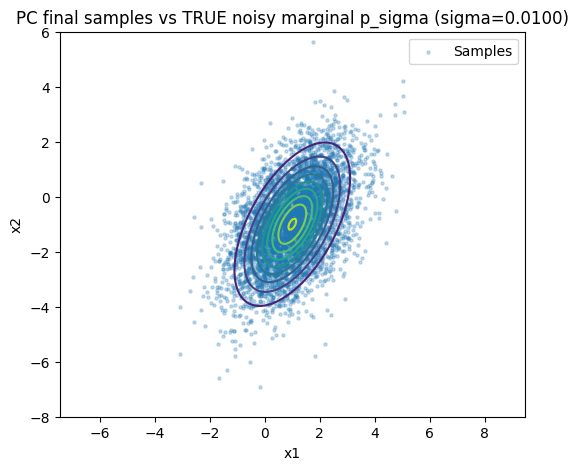


Global diagnostics (PC final samples vs TRUE noisy marginal)
(sigma = 0.010000, target N(mu, Sigma + sigma^2 I))
Generated mean: [ 0.99973184 -0.9310061 ]
True mean:      [ 1. -1.]
Mean error:     [-0.00026816  0.06899393]

Generated covariance:
 [[1.21637483 0.78578252]
 [0.78578252 2.11132295]]
True covariance (noisy marginal):
 [[1.0001 0.8   ]
 [0.8    2.0001]]
Covariance error:
 [[ 0.21627483 -0.01421748]
 [-0.01421748  0.11122295]]


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ============================================================
# 1) Data: correlated bivariate Gaussian p_data(x) = N(mu, Sigma)
# ============================================================
def sample_bivariate_normal(n: int, mu, Sigma, device="cpu"):
    mu = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma = torch.tensor(Sigma, dtype=torch.float32, device=device)
    L = torch.linalg.cholesky(Sigma)
    z = torch.randn(n, 2, device=device)
    return mu + z @ L.T


# ============================================================
# 2) MLP score model: s_theta(x_tilde, sigma)
#    input  = (x1, x2, log sigma)
#    output = (score1, score2)
# ============================================================
class ScoreNetMLP(nn.Module):
    def __init__(self, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_tilde, sigma):
        # sigma: (B,)  -> log_sigma: (B,1)
        log_sigma = torch.log(sigma).unsqueeze(1)
        inp = torch.cat([x_tilde, log_sigma], dim=1)  # (B,3)
        return self.net(inp)  # (B,2)


# ============================================================
# 3) VE denoising score matching (DSM) training loop
#    corruption: x_tilde = x + sigma * eps
#    target:     -(x_tilde - x)/sigma^2 = -eps/sigma
# ============================================================
def train_dsm(
    model,
    dataloader,
    sigmas,
    steps=5000,
    lr=1e-3,
    device="cpu",
    sigma_weight=True,
):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sigmas = torch.tensor(sigmas, dtype=torch.float32, device=device)  # (K,)

    it = iter(dataloader)
    for step in range(1, steps + 1):
        try:
            x = next(it)[0].to(device)  # (B,2)
        except StopIteration:
            it = iter(dataloader)
            x = next(it)[0].to(device)

        B = x.shape[0]

        # pick a sigma per datapoint (uniform over schedule)
        idx = torch.randint(0, sigmas.numel(), (B,), device=device)
        sigma = sigmas[idx]  # (B,)

        # add VE noise
        eps = torch.randn_like(x)  # (B,2)
        x_tilde = x + sigma.unsqueeze(1) * eps

        # DSM target = score of q(x_tilde|x)
        target = -eps / sigma.unsqueeze(1)  # (B,2)

        pred = model(x_tilde, sigma)  # (B,2)

        # common NCSN-style weighting
        if sigma_weight:
            w = (sigma**2).unsqueeze(1)  # (B,1)
            loss = ((pred - target) ** 2 * w).mean()
        else:
            loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 500 == 0:
            print(f"step {step:5d} | loss {loss.item():.6f}")

    return model


# ============================================================
# 4) True intermediate (noisy marginal) distribution for toy Gaussian
#
# If x ~ N(mu, Sigma) and x_tilde = x + sigma * eps, eps~N(0,I)
# then the marginal of x_tilde is:
#   p_sigma(x_tilde) = N(mu, Sigma + sigma^2 I)
# and its score is:
#   ∇ log p_sigma(x_tilde) = -(Sigma + sigma^2 I)^{-1} (x_tilde - mu)
# ============================================================
def true_noisy_marginal_score(x_tilde, mu, Sigma, sigma):
    device = x_tilde.device
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    Sigma_inv = torch.linalg.inv(Sigma_sigma)
    return -(x_tilde - mu_t) @ Sigma_inv.T


def sample_from_noisy_marginal(n_samples, mu, Sigma, sigma, device="cpu"):
    """
    Sample x ~ N(mu, Sigma + sigma^2 I), the VE noisy marginal at noise level sigma.
    Matches forward corruption marginal when data is N(mu, Sigma).
    """
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    L = torch.linalg.cholesky(Sigma_sigma)
    z = torch.randn(n_samples, 2, device=device)
    return mu_t + z @ L.T


@torch.no_grad()
def eval_mse_cosine_per_sigma(model, mu, Sigma, sigmas, device="cpu", n_test=5000):
    """
    Compare model(x, sigma) to TRUE noisy marginal score at each sigma.
    Returns arrays so you can plot MSE vs sigma.
    """
    model.eval()
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)

    mses, coses = [], []
    for s in sigmas:
        s = float(s)

        # sample x_tilde from the TRUE noisy marginal N(mu, Sigma + s^2 I)
        Sigma_sigma = Sigma_t + (s**2) * torch.eye(2, device=device)
        L = torch.linalg.cholesky(Sigma_sigma)
        z = torch.randn(n_test, 2, device=device)
        x_tilde = mu_t + z @ L.T

        sigma_batch = torch.full((n_test,), s, device=device)
        pred = model(x_tilde, sigma_batch)
        true = true_noisy_marginal_score(x_tilde, mu, Sigma, s)

        mse = ((pred - true) ** 2).mean().item()
        cos = F.cosine_similarity(pred, true, dim=1).mean().item()
        mses.append(mse)
        coses.append(cos)

    return np.array(mses), np.array(coses)


def plot_mse_vs_sigma(sigmas, mses):
    plt.figure(figsize=(6, 4))
    plt.plot(sigmas, mses, marker="o")
    plt.xscale("log")
    plt.xlabel("sigma (log scale)")
    plt.ylabel("MSE")
    plt.title("MSE vs Noise Level (sigma)")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


# ============================================================
# 5) VE sampling: Annealed Langevin dynamics
#    x <- x + eta * s_theta(x, sigma) + sqrt(2 eta) z
# ============================================================
@torch.no_grad()
def sample_annealed_langevin_with_snapshots(
    model,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
    mu=None,
    Sigma=None,
):
    """
    Runs annealed Langevin across a decreasing sigma schedule.
    Optionally stores x when we first reach each sigma in snapshot_sigmas.

    Returns:
      final_x: (n_samples,2) torch tensor
      snaps: dict {sigma_value: x_tensor_copy}
    """
    model.eval()
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    if mu is not None and Sigma is not None:
        x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)
    else:
        x = torch.randn(n_samples, 2, device=device) * sigma_max

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    # iterate from large -> small
    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())

        sigma_batch = torch.full((n_samples,), s_val, device=device)

        # NCSN-style annealed Langevin: normalize by sigma_min
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_batch) + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    # Optional final denoise at sigma_min (no injected noise)
    if denoise:
        s_min = float(sigma_min.item())
        sigma_batch = torch.full((n_samples,), s_min, device=device)
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            x = x + eta_denoise * model(x, sigma_batch)

    return x, snaps


@torch.no_grad()
def sample_pc_reverse_sde(
    model,
    sigmas,
    n_samples=5000,
    n_corrector_steps=2,
    corrector_step_scale=1e-5,
    device="cpu",
    denoise=False,
    mu=None,
    Sigma=None,
):
    """
    Predictor-Corrector (PC) sampler for VE using learned score.

    Predictor: reverse-SDE Euler-Maruyama step between adjacent sigmas
      x <- x + (sigma_i^2 - sigma_{i+1}^2) s_theta(x, sigma_i)
             + sqrt(sigma_i^2 - sigma_{i+1}^2) z

    Corrector: Langevin refinement at fixed sigma_{i+1}
      x <- x + eta s_theta(x, sigma_{i+1}) + sqrt(2 eta) z
    """
    model.eval()
    sigmas_sorted = np.array(sorted([float(s) for s in sigmas], reverse=True), dtype=np.float32)
    sigmas_t = torch.tensor(sigmas_sorted, dtype=torch.float32, device=device)
    sigma_min = sigmas_t[-1]

    # For this toy Gaussian, start from the true noisy marginal at sigma_max if available.
    # Falling back to N(0, sigma_max^2 I) keeps generic behavior.
    if mu is not None and Sigma is not None:
        x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigmas_t[0].item()), device=device)
    else:
        x = torch.randn(n_samples, 2, device=device) * sigmas_t[0]

    for i in range(len(sigmas_t) - 1):
        sigma_i = float(sigmas_t[i].item())
        sigma_next = float(sigmas_t[i + 1].item())

        # Predictor (reverse SDE Euler-Maruyama)
        sigma_i_batch = torch.full((n_samples,), sigma_i, device=device)
        score_i = model(x, sigma_i_batch)
        delta_var = sigma_i**2 - sigma_next**2
        z = torch.randn_like(x)
        x = x + delta_var * score_i + (delta_var**0.5) * z

        # Corrector (Langevin at sigma_next)
        sigma_next_batch = torch.full((n_samples,), sigma_next, device=device)
        eta = float(corrector_step_scale * ((sigma_next / float(sigma_min.item())) ** 2))
        for _ in range(n_corrector_steps):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_next_batch) + (2 * eta) ** 0.5 * z

    if denoise:
        sigma_last = float(sigma_min.item())
        sigma_last_batch = torch.full((n_samples,), sigma_last, device=device)
        x = x + (sigma_last**2) * model(x, sigma_last_batch)

    return x


@torch.no_grad()
def sample_annealed_langevin_exact_score_with_snapshots(
    mu,
    Sigma,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
):
    """
    Same annealed Langevin sampler, but using the TRUE score at each sigma.
    Useful sanity check to isolate sampling dynamics from score-learning error.
    """
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_val)
            x = x + eta * true_score + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    if denoise:
        s_min = float(sigma_min.item())
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_min)
            x = x + eta_denoise * true_score

    return x, snaps


@torch.no_grad()
def sample_fixed_sigma_exact_langevin(
    mu,
    Sigma,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    device="cpu",
    init_sigma=1.0,
):
    """
    Ordinary (non-annealed) Langevin dynamics at a single noise level sigma_fixed,
    using the exact score of the noisy marginal p_sigma = N(mu, Sigma + sigma_fixed^2 I).

        x <- x + eta * grad log p_sigma(x) + sqrt(2 eta) z

    Chains are initialised from N(mu, Sigma + init_sigma^2 I) (e.g. init_sigma=1.0
    matches a high-noise forward marginal) so the run is a convergence check toward p_sigma.
    """
    x = sample_from_noisy_marginal(n_samples, mu, Sigma, init_sigma, device=device)
    s_fixed = float(sigma_fixed)

    for _ in range(n_steps):
        z = torch.randn_like(x)
        score = true_noisy_marginal_score(x, mu, Sigma, s_fixed)
        x = x + eta * score + (2 * eta) ** 0.5 * z

    return x


def run_fixed_sigma_exact_langevin_experiment(
    mu,
    Sigma,
    device=None,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    init_sigma=1.0,
):
    """
    Separate experiment: fixed-sigma exact-score Langevin targeting p_sigma only.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print("\n" + "=" * 60)
    print(
        f"Fixed-sigma exact Langevin (sigma={sigma_fixed}): "
        f"target N(mu, Sigma + sigma^2 I), ordinary Langevin, no annealing"
    )
    print("=" * 60)

    x = sample_fixed_sigma_exact_langevin(
        mu,
        Sigma,
        sigma_fixed=sigma_fixed,
        n_samples=n_samples,
        n_steps=n_steps,
        eta=eta,
        device=device,
        init_sigma=init_sigma,
    )
    samples_np = x.cpu().numpy()

    plot_samples_vs_true_noisy_marginal(
        samples_np,
        mu,
        Sigma,
        sigma=sigma_fixed,
        levels=12,
        span=7.0,
        title=f"Fixed sigma={sigma_fixed}: exact-score Langevin vs TRUE p_sigma",
    )

    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64) + (sigma_fixed**2) * np.eye(2)
    mean_s = samples_np.mean(axis=0)
    cov_s = np.cov(samples_np.T)

    print("\nSample mean:", mean_s)
    print("True mean (same for all sigma):", mean_true)
    print("\nSample covariance:\n", cov_s)
    print("True covariance at sigma:\n", cov_true)
    print("Mean L2 error:", np.linalg.norm(mean_s - mean_true))
    print("Cov Frobenius error:", np.linalg.norm(cov_s - cov_true, ord="fro"))

    return x


# ============================================================
# 6) Plot: sampled points vs TRUE intermediate marginal contours
#    TRUE intermediate marginal at sigma is N(mu, Sigma + sigma^2 I)
# ============================================================
def gaussian_density_grid(mu, Sigma, x1, x2):
    """
    Compute 2D Gaussian density on a grid given by meshgrid(x1, x2).
    Returns Z with shape (len(x2), len(x1)) suitable for contour.
    """
    mu = np.array(mu, dtype=np.float64)
    Sigma = np.array(Sigma, dtype=np.float64)
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)

    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    X = np.stack([X1, X2], axis=-1)  # (...,2)
    D = X - mu
    quad = np.einsum("...i,ij,...j->...", D, inv, D)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    Z = norm * np.exp(-0.5 * quad)
    return X1, X2, Z


def plot_samples_vs_true_noisy_marginal(samples_np, mu, Sigma, sigma, levels=12, span=7.0, title=None):
    """
    Overlay sampled points with contours of the TRUE noisy marginal at this sigma:
      N(mu, Sigma + sigma^2 I)
    """
    Sigma = np.array(Sigma, dtype=np.float64)
    Sigma_sigma = Sigma + (sigma**2) * np.eye(2)

    x1 = np.linspace(mu[0] - span, mu[0] + span, 200)
    x2 = np.linspace(mu[1] - span, mu[1] + span, 200)
    X1, X2, Z = gaussian_density_grid(mu, Sigma_sigma, x1, x2)

    plt.figure(figsize=(6, 5))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=5, alpha=0.25, label="Samples")
    plt.contour(X1, X2, Z, levels=levels)
    plt.xlabel("x1")
    plt.ylabel("x2")
    if title is None:
        title = f"Samples vs TRUE noisy marginal contours (sigma={sigma:.4f})"
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()


# ============================================================
# 7) Run everything
# ============================================================
def run_experiment():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(0)
    np.random.seed(0)

    # --- toy target distribution ---
    mu = [1.0, -1.0]
    Sigma = [[1.0, 0.8],
             [0.8, 2.0]]

    # --- dataset ---
    N = 20000
    x = sample_bivariate_normal(N, mu, Sigma, device=device).cpu()
    loader = DataLoader(TensorDataset(x), batch_size=512, shuffle=True, drop_last=True)

    # --- VE noise schedule (your "time parameter" in practice) ---
    sigmas = np.geomspace(1.0, 0.01, 10).astype(np.float32)
    sigma_final = float(sigmas[-1])  # smallest sigma: compare to p_sigma at this level
    # --- model ---
    model = ScoreNetMLP(hidden_dim=128).to(device)

    # --- train ---
    train_dsm(model, loader, sigmas, steps=5000, lr=1e-3, device=device, sigma_weight=True)

    # --- PC sampling (predictor + corrector) with learned score ---
    final_x = sample_pc_reverse_sde(
        model,
        sigmas,
        n_samples=5000,
        n_corrector_steps=2,
        corrector_step_scale=1e-5,
        device=device,
        denoise=True,
        mu=mu,
        Sigma=Sigma,
    )

    # Final learned samples vs TRUE noisy marginal N(mu, Sigma + sigma_final^2 I)
    final_np = final_x.cpu().numpy()
    plot_samples_vs_true_noisy_marginal(
        final_np, mu, Sigma, sigma=sigma_final, levels=12, span=7.0,
        title=f"PC final samples vs TRUE noisy marginal p_sigma (sigma={sigma_final:.4f})"
    )

    mean_gen = final_np.mean(axis=0)
    cov_gen = np.cov(final_np.T)
    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64) + (sigma_final**2) * np.eye(2)

    print("\nGlobal diagnostics (PC final samples vs TRUE noisy marginal)")
    print(f"(sigma = {sigma_final:.6f}, target N(mu, Sigma + sigma^2 I))")
    print("Generated mean:", mean_gen)
    print("True mean:     ", mean_true)
    print("Mean error:    ", mean_gen - mean_true)
    print("\nGenerated covariance:\n", cov_gen)
    print("True covariance (noisy marginal):\n", cov_true)
    print("Covariance error:\n", cov_gen - cov_true)

    return model, sigmas, mu, Sigma


if __name__ == "__main__":
    run_experiment()

step   500 | loss 0.887534
step  1000 | loss 0.953802
step  1500 | loss 0.837106
step  2000 | loss 0.887523
step  2500 | loss 0.907862
step  3000 | loss 0.947181
step  3500 | loss 0.866949
step  4000 | loss 0.927982
step  4500 | loss 0.843044
step  5000 | loss 0.914781

Diagnostics vs TRUE noisy marginal score
   sigma        MSE        cosine
  1.0000    0.004026     0.9875
  0.5995    0.011145     0.9780
  0.3594    0.017232     0.9714
  0.2154    0.026191     0.9541
  0.1292    0.034933     0.9520
  0.0774    0.041470     0.9532
  0.0464    0.055189     0.9644
  0.0278    0.086281     0.9705
  0.0167    0.145801     0.9501
  0.0100    0.220870     0.8948


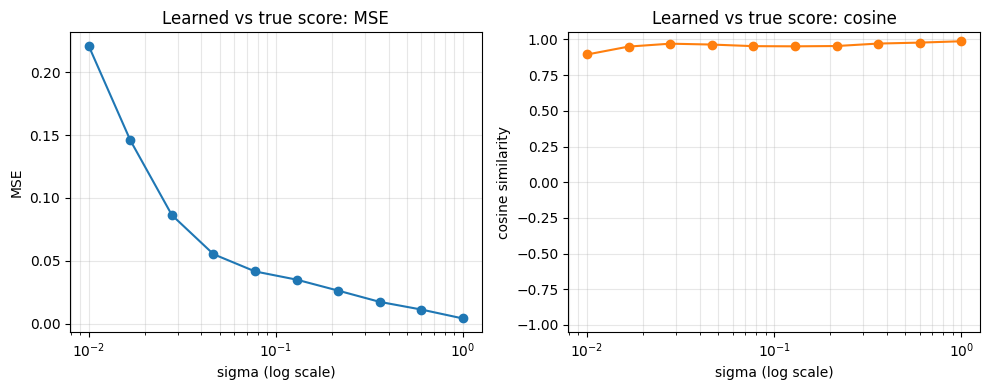

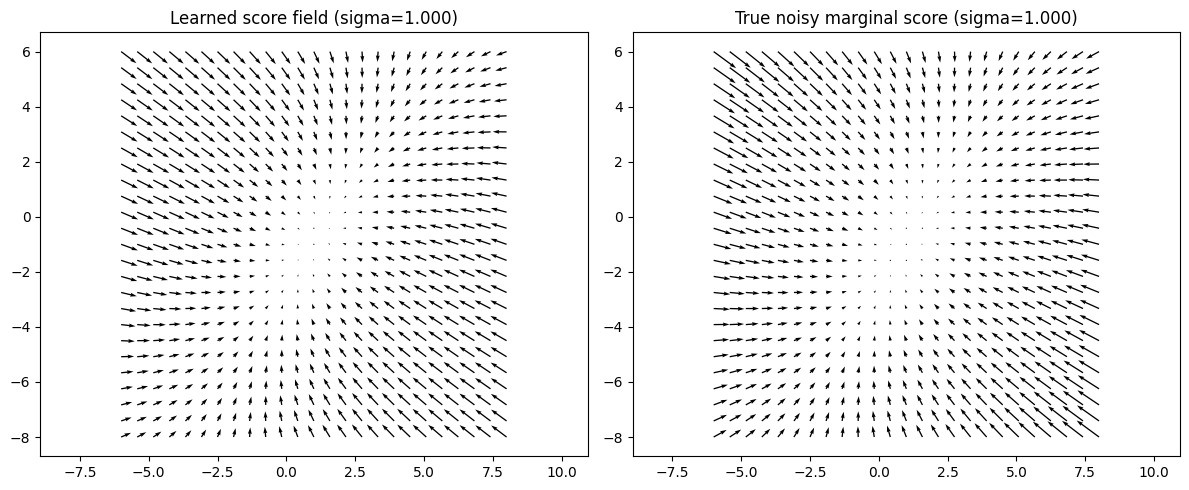

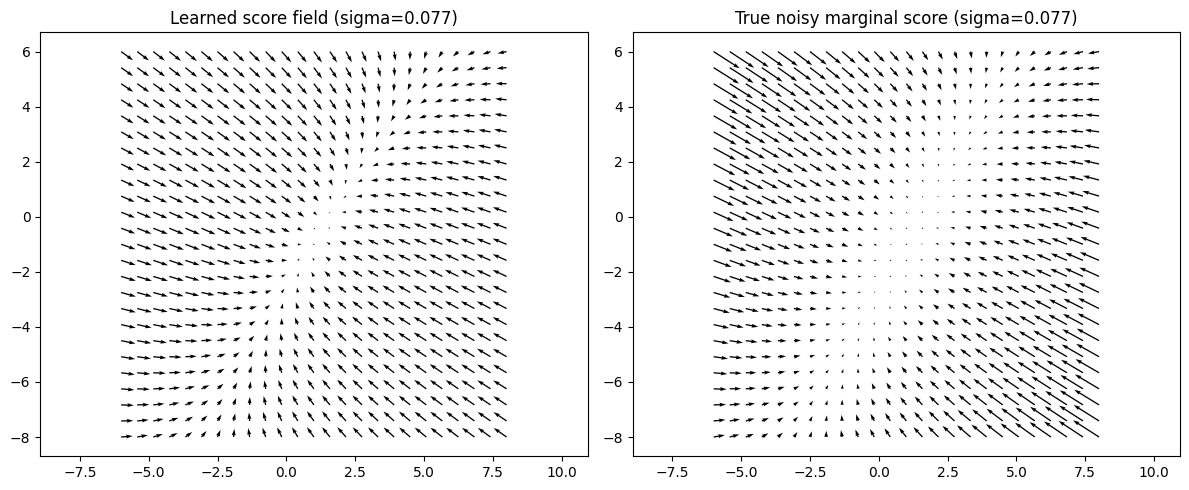

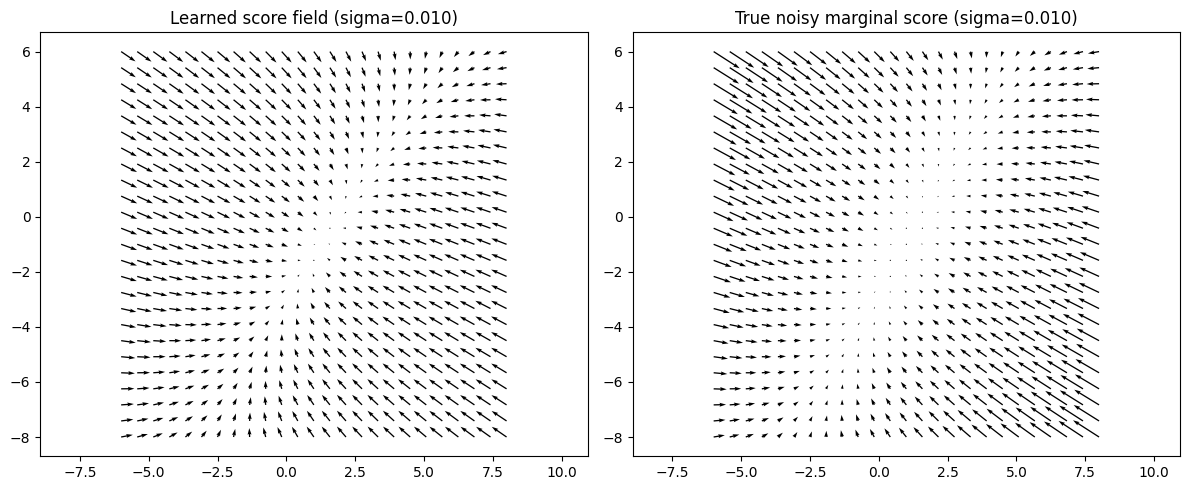

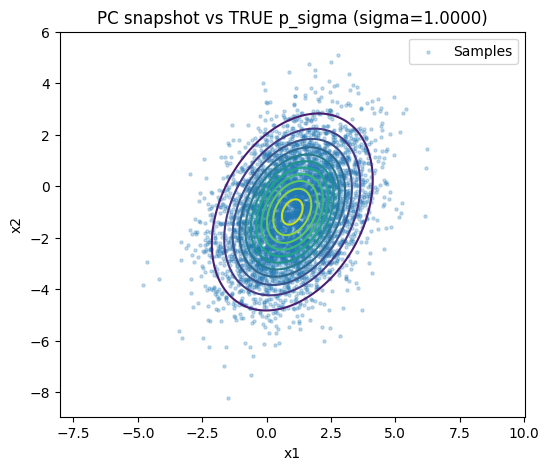

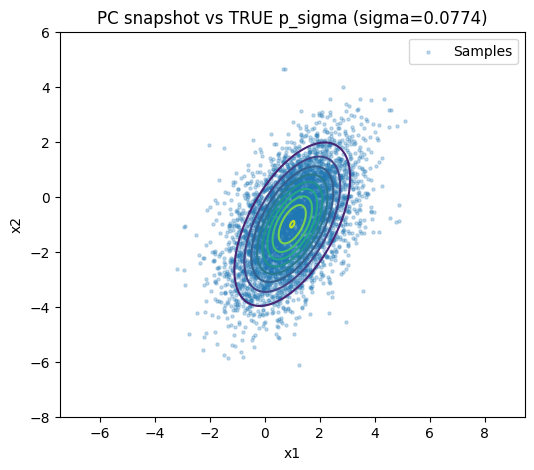

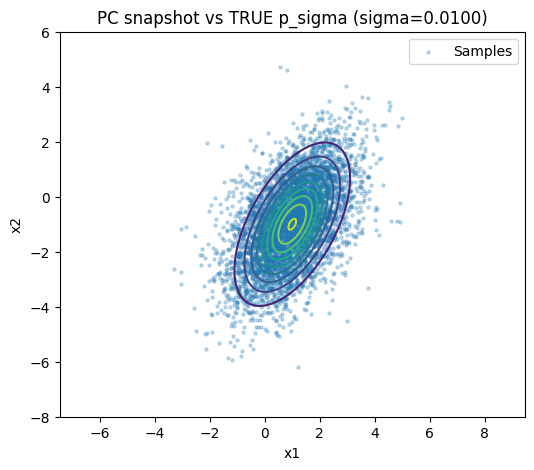

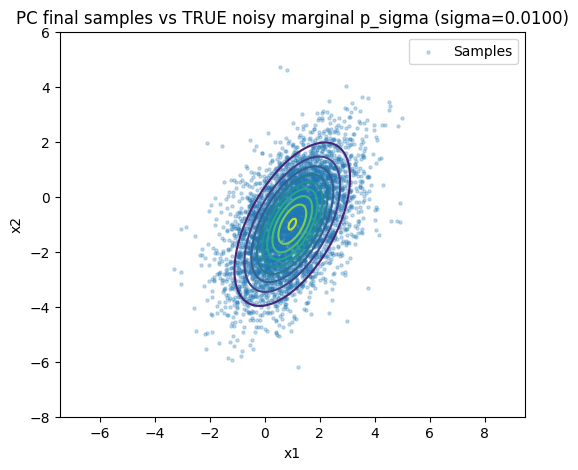


Global diagnostics (PC final samples vs TRUE noisy marginal)
(sigma = 0.010000, target N(mu, Sigma + sigma^2 I))
Generated mean: [ 0.9627387 -0.9361333]
True mean:      [ 1. -1.]
Mean error:     [-0.03726131  0.06386667]

Generated covariance:
 [[1.24688276 0.84041108]
 [0.84041108 2.18715687]]
True covariance (noisy marginal):
 [[1.0001 0.8   ]
 [0.8    2.0001]]
Covariance error:
 [[0.24678276 0.04041108]
 [0.04041108 0.18705687]]


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ============================================================
# 1) Data: correlated bivariate Gaussian p_data(x) = N(mu, Sigma)
# ============================================================
def sample_bivariate_normal(n: int, mu, Sigma, device="cpu"):
    mu = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma = torch.tensor(Sigma, dtype=torch.float32, device=device)
    L = torch.linalg.cholesky(Sigma)
    z = torch.randn(n, 2, device=device)
    return mu + z @ L.T


# ============================================================
# 2) MLP score model: s_theta(x_tilde, sigma)
#    input  = (x1, x2, log sigma)
#    output = (score1, score2)
# ============================================================
class ScoreNetMLP(nn.Module):
    def __init__(self, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_tilde, sigma):
        # sigma: (B,)  -> log_sigma: (B,1)
        log_sigma = torch.log(sigma).unsqueeze(1)
        inp = torch.cat([x_tilde, log_sigma], dim=1)  # (B,3)
        return self.net(inp)  # (B,2)


# ============================================================
# 3) VE denoising score matching (DSM) training loop
#    corruption: x_tilde = x + sigma * eps
#    target:     -(x_tilde - x)/sigma^2 = -eps/sigma
# ============================================================
def train_dsm(
    model,
    dataloader,
    sigmas,
    steps=5000,
    lr=1e-3,
    device="cpu",
    sigma_weight=True,
):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sigmas = torch.tensor(sigmas, dtype=torch.float32, device=device)  # (K,)

    it = iter(dataloader)
    for step in range(1, steps + 1):
        try:
            x = next(it)[0].to(device)  # (B,2)
        except StopIteration:
            it = iter(dataloader)
            x = next(it)[0].to(device)

        B = x.shape[0]

        # pick a sigma per datapoint (uniform over schedule)
        idx = torch.randint(0, sigmas.numel(), (B,), device=device)
        sigma = sigmas[idx]  # (B,)

        # add VE noise
        eps = torch.randn_like(x)  # (B,2)
        x_tilde = x + sigma.unsqueeze(1) * eps

        # DSM target = score of q(x_tilde|x)
        target = -eps / sigma.unsqueeze(1)  # (B,2)

        pred = model(x_tilde, sigma)  # (B,2)

        # common NCSN-style weighting
        if sigma_weight:
            w = (sigma**2).unsqueeze(1)  # (B,1)
            loss = ((pred - target) ** 2 * w).mean()
        else:
            loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 500 == 0:
            print(f"step {step:5d} | loss {loss.item():.6f}")

    return model


# ============================================================
# 4) True intermediate (noisy marginal) distribution for toy Gaussian
#
# If x ~ N(mu, Sigma) and x_tilde = x + sigma * eps, eps~N(0,I)
# then the marginal of x_tilde is:
#   p_sigma(x_tilde) = N(mu, Sigma + sigma^2 I)
# and its score is:
#   ∇ log p_sigma(x_tilde) = -(Sigma + sigma^2 I)^{-1} (x_tilde - mu)
# ============================================================
def true_noisy_marginal_score(x_tilde, mu, Sigma, sigma):
    device = x_tilde.device
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    Sigma_inv = torch.linalg.inv(Sigma_sigma)
    return -(x_tilde - mu_t) @ Sigma_inv.T


def sample_from_noisy_marginal(n_samples, mu, Sigma, sigma, device="cpu"):
    """
    Sample x ~ N(mu, Sigma + sigma^2 I), the VE noisy marginal at noise level sigma.
    Matches forward corruption marginal when data is N(mu, Sigma).
    """
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)
    Sigma_sigma = Sigma_t + (sigma**2) * torch.eye(2, device=device)
    L = torch.linalg.cholesky(Sigma_sigma)
    z = torch.randn(n_samples, 2, device=device)
    return mu_t + z @ L.T


@torch.no_grad()
def eval_mse_cosine_per_sigma(model, mu, Sigma, sigmas, device="cpu", n_test=5000):
    """
    Compare model(x, sigma) to TRUE noisy marginal score at each sigma.
    Returns arrays so you can plot MSE vs sigma.
    """
    model.eval()
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)
    Sigma_t = torch.tensor(Sigma, dtype=torch.float32, device=device)

    mses, coses = [], []
    for s in sigmas:
        s = float(s)

        # sample x_tilde from the TRUE noisy marginal N(mu, Sigma + s^2 I)
        Sigma_sigma = Sigma_t + (s**2) * torch.eye(2, device=device)
        L = torch.linalg.cholesky(Sigma_sigma)
        z = torch.randn(n_test, 2, device=device)
        x_tilde = mu_t + z @ L.T

        sigma_batch = torch.full((n_test,), s, device=device)
        pred = model(x_tilde, sigma_batch)
        true = true_noisy_marginal_score(x_tilde, mu, Sigma, s)

        mse = ((pred - true) ** 2).mean().item()
        cos = F.cosine_similarity(pred, true, dim=1).mean().item()
        mses.append(mse)
        coses.append(cos)

    return np.array(mses), np.array(coses)


def plot_mse_vs_sigma(sigmas, mses):
    plt.figure(figsize=(6, 4))
    plt.plot(sigmas, mses, marker="o")
    plt.xscale("log")
    plt.xlabel("sigma (log scale)")
    plt.ylabel("MSE")
    plt.title("MSE vs Noise Level (sigma)")
    plt.grid(True, which="both", alpha=0.3)
    plt.show()


def plot_mse_cosine_vs_sigma(sigmas, mses, coses):
    """Score learning diagnostics: MSE and cosine similarity vs sigma (like mixture script style)."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(sigmas, mses, marker="o")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("sigma (log scale)")
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Learned vs true score: MSE")
    axes[0].grid(True, which="both", alpha=0.3)

    axes[1].plot(sigmas, coses, marker="o", color="C1")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("sigma (log scale)")
    axes[1].set_ylabel("cosine similarity")
    axes[1].set_title("Learned vs true score: cosine")
    axes[1].set_ylim(-1.05, 1.05)
    axes[1].grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def plot_score_fields_gaussian(
    model,
    mu,
    Sigma,
    sigma,
    device="cpu",
    grid_n=25,
    span=7.0,
):
    """Learned vs true noisy marginal score field on a 2D grid (Gaussian mixture analogue)."""
    model.eval()
    sigma = float(sigma)
    mu_t = torch.tensor(mu, dtype=torch.float32, device=device)

    x1 = torch.linspace(mu_t[0] - span, mu_t[0] + span, grid_n, device=device)
    x2 = torch.linspace(mu_t[1] - span, mu_t[1] + span, grid_n, device=device)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")
    grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)

    sigma_batch = torch.full((grid.shape[0],), sigma, device=device)
    pred = model(grid, sigma_batch).cpu().numpy()
    true = true_noisy_marginal_score(grid, mu, Sigma, sigma).cpu().numpy()
    grid_np = grid.cpu().numpy()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.quiver(grid_np[:, 0], grid_np[:, 1], pred[:, 0], pred[:, 1])
    plt.title(f"Learned score field (sigma={sigma:.3f})")
    plt.axis("equal")

    plt.subplot(1, 2, 2)
    plt.quiver(grid_np[:, 0], grid_np[:, 1], true[:, 0], true[:, 1])
    plt.title(f"True noisy marginal score (sigma={sigma:.3f})")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()


# ============================================================
# 5) VE sampling: Annealed Langevin dynamics
#    x <- x + eta * s_theta(x, sigma) + sqrt(2 eta) z
# ============================================================
@torch.no_grad()
def sample_annealed_langevin_with_snapshots(
    model,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
    mu=None,
    Sigma=None,
):
    """
    Runs annealed Langevin across a decreasing sigma schedule.
    Optionally stores x when we first reach each sigma in snapshot_sigmas.

    Returns:
      final_x: (n_samples,2) torch tensor
      snaps: dict {sigma_value: x_tensor_copy}
    """
    model.eval()
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    if mu is not None and Sigma is not None:
        x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)
    else:
        x = torch.randn(n_samples, 2, device=device) * sigma_max

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    # iterate from large -> small
    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())

        sigma_batch = torch.full((n_samples,), s_val, device=device)

        # NCSN-style annealed Langevin: normalize by sigma_min
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_batch) + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    # Optional final denoise at sigma_min (no injected noise)
    if denoise:
        s_min = float(sigma_min.item())
        sigma_batch = torch.full((n_samples,), s_min, device=device)
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            x = x + eta_denoise * model(x, sigma_batch)

    return x, snaps


@torch.no_grad()
def sample_pc_reverse_sde(
    model,
    sigmas,
    n_samples=5000,
    n_corrector_steps=2,
    corrector_step_scale=1e-5,
    device="cpu",
    denoise=False,
    mu=None,
    Sigma=None,
    snapshot_sigmas=None,
):
    """
    Predictor-Corrector (PC) sampler for VE using learned score.

    Predictor: reverse-SDE Euler-Maruyama step between adjacent sigmas
      x <- x + (sigma_i^2 - sigma_{i+1}^2) s_theta(x, sigma_i)
             + sqrt(sigma_i^2 - sigma_{i+1}^2) z

    Corrector: Langevin refinement at fixed sigma_{i+1}
      x <- x + eta s_theta(x, sigma_{i+1}) + sqrt(2 eta) z

    Returns:
        final_x: (n_samples, 2)
        snaps: dict mapping sigma value -> tensor snapshot after finishing that noise level
    """
    model.eval()
    sigmas_sorted = np.array(sorted([float(s) for s in sigmas], reverse=True), dtype=np.float32)
    sigmas_t = torch.tensor(sigmas_sorted, dtype=torch.float32, device=device)
    sigma_min = sigmas_t[-1]

    snaps = {}
    snapshot_set = {float(s) for s in snapshot_sigmas} if snapshot_sigmas is not None else set()

    # For this toy Gaussian, start from the true noisy marginal at sigma_max if available.
    # Falling back to N(0, sigma_max^2 I) keeps generic behavior.
    if mu is not None and Sigma is not None:
        x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigmas_t[0].item()), device=device)
    else:
        x = torch.randn(n_samples, 2, device=device) * sigmas_t[0]

    s0 = float(sigmas_t[0].item())
    if s0 in snapshot_set and s0 not in snaps:
        snaps[s0] = x.detach().clone()

    for i in range(len(sigmas_t) - 1):
        sigma_i = float(sigmas_t[i].item())
        sigma_next = float(sigmas_t[i + 1].item())

        # Predictor (reverse SDE Euler-Maruyama)
        sigma_i_batch = torch.full((n_samples,), sigma_i, device=device)
        score_i = model(x, sigma_i_batch)
        delta_var = sigma_i**2 - sigma_next**2
        z = torch.randn_like(x)
        x = x + delta_var * score_i + (delta_var**0.5) * z

        # Corrector (Langevin at sigma_next)
        sigma_next_batch = torch.full((n_samples,), sigma_next, device=device)
        eta = float(corrector_step_scale * ((sigma_next / float(sigma_min.item())) ** 2))
        for _ in range(n_corrector_steps):
            z = torch.randn_like(x)
            x = x + eta * model(x, sigma_next_batch) + (2 * eta) ** 0.5 * z

        if sigma_next in snapshot_set and sigma_next not in snaps:
            snaps[sigma_next] = x.detach().clone()

    if denoise:
        sigma_last = float(sigma_min.item())
        sigma_last_batch = torch.full((n_samples,), sigma_last, device=device)
        x = x + (sigma_last**2) * model(x, sigma_last_batch)

    return x, snaps


@torch.no_grad()
def sample_annealed_langevin_exact_score_with_snapshots(
    mu,
    Sigma,
    sigmas,
    n_samples=5000,
    n_steps_each=500,
    step_scale=1e-5,
    device="cpu",
    snapshot_sigmas=None,
    extra_steps_at_end=0,
    denoise=False,
    denoise_steps=None,
):
    """
    Same annealed Langevin sampler, but using the TRUE score at each sigma.
    Useful sanity check to isolate sampling dynamics from score-learning error.
    """
    sigmas_t = torch.tensor(sigmas, dtype=torch.float32, device=device)
    sigma_min = sigmas_t.min()
    sigma_max = sigmas_t.max()

    x = sample_from_noisy_marginal(n_samples, mu, Sigma, float(sigma_max.item()), device=device)

    snaps = {}
    snapshot_set = set([float(s) for s in snapshot_sigmas]) if snapshot_sigmas is not None else set()

    for sigma in sigmas_t.flip(0):
        s_val = float(sigma.item())
        eta = step_scale * ((sigma / sigma_min) ** 2)
        steps_here = n_steps_each
        if np.isclose(s_val, float(sigma_min.item())):
            steps_here = n_steps_each + int(extra_steps_at_end)

        for _ in range(steps_here):
            z = torch.randn_like(x)
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_val)
            x = x + eta * true_score + (2 * eta) ** 0.5 * z

        if s_val in snapshot_set and (s_val not in snaps):
            snaps[s_val] = x.detach().clone()

    if denoise:
        s_min = float(sigma_min.item())
        denoise_steps = max(1, int(n_steps_each // 5)) if denoise_steps is None else int(denoise_steps)
        eta_denoise = step_scale
        for _ in range(denoise_steps):
            true_score = true_noisy_marginal_score(x, mu, Sigma, s_min)
            x = x + eta_denoise * true_score

    return x, snaps


@torch.no_grad()
def sample_fixed_sigma_exact_langevin(
    mu,
    Sigma,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    device="cpu",
    init_sigma=1.0,
):
    """
    Ordinary (non-annealed) Langevin dynamics at a single noise level sigma_fixed,
    using the exact score of the noisy marginal p_sigma = N(mu, Sigma + sigma_fixed^2 I).

        x <- x + eta * grad log p_sigma(x) + sqrt(2 eta) z

    Chains are initialised from N(mu, Sigma + init_sigma^2 I) (e.g. init_sigma=1.0
    matches a high-noise forward marginal) so the run is a convergence check toward p_sigma.
    """
    x = sample_from_noisy_marginal(n_samples, mu, Sigma, init_sigma, device=device)
    s_fixed = float(sigma_fixed)

    for _ in range(n_steps):
        z = torch.randn_like(x)
        score = true_noisy_marginal_score(x, mu, Sigma, s_fixed)
        x = x + eta * score + (2 * eta) ** 0.5 * z

    return x


def run_fixed_sigma_exact_langevin_experiment(
    mu,
    Sigma,
    device=None,
    sigma_fixed=0.1,
    n_samples=5000,
    n_steps=20000,
    eta=1e-5,
    init_sigma=1.0,
):
    """
    Separate experiment: fixed-sigma exact-score Langevin targeting p_sigma only.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print("\n" + "=" * 60)
    print(
        f"Fixed-sigma exact Langevin (sigma={sigma_fixed}): "
        f"target N(mu, Sigma + sigma^2 I), ordinary Langevin, no annealing"
    )
    print("=" * 60)

    x = sample_fixed_sigma_exact_langevin(
        mu,
        Sigma,
        sigma_fixed=sigma_fixed,
        n_samples=n_samples,
        n_steps=n_steps,
        eta=eta,
        device=device,
        init_sigma=init_sigma,
    )
    samples_np = x.cpu().numpy()

    plot_samples_vs_true_noisy_marginal(
        samples_np,
        mu,
        Sigma,
        sigma=sigma_fixed,
        levels=12,
        span=7.0,
        title=f"Fixed sigma={sigma_fixed}: exact-score Langevin vs TRUE p_sigma",
    )

    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64) + (sigma_fixed**2) * np.eye(2)
    mean_s = samples_np.mean(axis=0)
    cov_s = np.cov(samples_np.T)

    print("\nSample mean:", mean_s)
    print("True mean (same for all sigma):", mean_true)
    print("\nSample covariance:\n", cov_s)
    print("True covariance at sigma:\n", cov_true)
    print("Mean L2 error:", np.linalg.norm(mean_s - mean_true))
    print("Cov Frobenius error:", np.linalg.norm(cov_s - cov_true, ord="fro"))

    return x


# ============================================================
# 6) Plot: sampled points vs TRUE intermediate marginal contours
#    TRUE intermediate marginal at sigma is N(mu, Sigma + sigma^2 I)
# ============================================================
def gaussian_density_grid(mu, Sigma, x1, x2):
    """
    Compute 2D Gaussian density on a grid given by meshgrid(x1, x2).
    Returns Z with shape (len(x2), len(x1)) suitable for contour.
    """
    mu = np.array(mu, dtype=np.float64)
    Sigma = np.array(Sigma, dtype=np.float64)
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)

    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    X = np.stack([X1, X2], axis=-1)  # (...,2)
    D = X - mu
    quad = np.einsum("...i,ij,...j->...", D, inv, D)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    Z = norm * np.exp(-0.5 * quad)
    return X1, X2, Z


def plot_samples_vs_true_noisy_marginal(samples_np, mu, Sigma, sigma, levels=12, span=7.0, title=None):
    """
    Overlay sampled points with contours of the TRUE noisy marginal at this sigma:
      N(mu, Sigma + sigma^2 I)
    """
    Sigma = np.array(Sigma, dtype=np.float64)
    Sigma_sigma = Sigma + (sigma**2) * np.eye(2)

    x1 = np.linspace(mu[0] - span, mu[0] + span, 200)
    x2 = np.linspace(mu[1] - span, mu[1] + span, 200)
    X1, X2, Z = gaussian_density_grid(mu, Sigma_sigma, x1, x2)

    plt.figure(figsize=(6, 5))
    plt.scatter(samples_np[:, 0], samples_np[:, 1], s=5, alpha=0.25, label="Samples")
    plt.contour(X1, X2, Z, levels=levels)
    plt.xlabel("x1")
    plt.ylabel("x2")
    if title is None:
        title = f"Samples vs TRUE noisy marginal contours (sigma={sigma:.4f})"
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()


# ============================================================
# 7) Run everything
# ============================================================
def run_experiment():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(0)
    np.random.seed(0)

    # --- toy target distribution ---
    mu = [1.0, -1.0]
    Sigma = [[1.0, 0.8],
             [0.8, 2.0]]

    # --- dataset ---
    N = 20000
    x = sample_bivariate_normal(N, mu, Sigma, device=device).cpu()
    loader = DataLoader(TensorDataset(x), batch_size=512, shuffle=True, drop_last=True)

    # --- VE noise schedule (your "time parameter" in practice) ---
    sigmas = np.geomspace(1.0, 0.01, 10).astype(np.float32)
    sigma_final = float(sigmas[-1])  # smallest sigma: compare to p_sigma at this level
    # --- model ---
    model = ScoreNetMLP(hidden_dim=128).to(device)

    # --- train ---
    train_dsm(model, loader, sigmas, steps=5000, lr=1e-3, device=device, sigma_weight=True)

    # --- score learning diagnostics (MSE + cosine vs true noisy marginal score) ---
    mses, coses = eval_mse_cosine_per_sigma(model, mu, Sigma, sigmas, device=device, n_test=8000)
    print("\nDiagnostics vs TRUE noisy marginal score")
    print("   sigma        MSE        cosine")
    for s, mse, cos in zip(sigmas, mses, coses):
        print(f"{float(s):8.4f}  {mse:10.6f}   {cos:8.4f}")
    plot_mse_cosine_vs_sigma(sigmas, mses, coses)

    # --- intermediate: learned vs true score fields (same idea as mixture script) ---
    for s in [float(sigmas[0]), float(sigmas[len(sigmas) // 2]), float(sigmas[-1])]:
        plot_score_fields_gaussian(model, mu, Sigma, sigma=s, device=device, grid_n=25, span=7.0)

    snapshot_sigmas = [float(sigmas[0]), float(sigmas[len(sigmas) // 2]), float(sigmas[-1])]

    # --- PC sampling (predictor + corrector) with learned score + intermediate snapshots ---
    final_x, snaps = sample_pc_reverse_sde(
        model,
        sigmas,
        n_samples=5000,
        n_corrector_steps=2,
        corrector_step_scale=1e-5,
        device=device,
        denoise=True,
        mu=mu,
        Sigma=Sigma,
        snapshot_sigmas=snapshot_sigmas,
    )

    for s in snapshot_sigmas:
        if s not in snaps:
            continue
        x_s = snaps[s].cpu().numpy()
        plot_samples_vs_true_noisy_marginal(
            x_s, mu, Sigma, sigma=s, levels=12, span=7.0,
            title=f"PC snapshot vs TRUE p_sigma (sigma={s:.4f})",
        )

    # Final learned samples vs TRUE noisy marginal N(mu, Sigma + sigma_final^2 I)
    final_np = final_x.cpu().numpy()
    plot_samples_vs_true_noisy_marginal(
        final_np, mu, Sigma, sigma=sigma_final, levels=12, span=7.0,
        title=f"PC final samples vs TRUE noisy marginal p_sigma (sigma={sigma_final:.4f})"
    )

    mean_gen = final_np.mean(axis=0)
    cov_gen = np.cov(final_np.T)
    mean_true = np.array(mu, dtype=np.float64)
    cov_true = np.array(Sigma, dtype=np.float64) + (sigma_final**2) * np.eye(2)

    print("\nGlobal diagnostics (PC final samples vs TRUE noisy marginal)")
    print(f"(sigma = {sigma_final:.6f}, target N(mu, Sigma + sigma^2 I))")
    print("Generated mean:", mean_gen)
    print("True mean:     ", mean_true)
    print("Mean error:    ", mean_gen - mean_true)
    print("\nGenerated covariance:\n", cov_gen)
    print("True covariance (noisy marginal):\n", cov_true)
    print("Covariance error:\n", cov_gen - cov_true)

    return model, sigmas, mu, Sigma


if __name__ == "__main__":
    run_experiment()